# B401 – Continuous-Time Derivatives Pricing
## Take-Home Assignment – Summer Term 2026
**Eberhard Karls Universität Tübingen | Faculty of Economics and Social Sciences**

---
**Name:** DAANISH MUZAFFAR 

**Student ID:** 7259472   

---

## Setup – Imports, Data & Global Parameters

The notebook relies on a small, well-established Python stack: `numpy` and `pandas` for numerical operations and time-series handling; `scipy.stats.norm` for Black-Scholes closed-form analytics; `scipy.optimize.brentq` for root-finding in Task XI; `yfinance` for downloading Rheinmetall AG market data; and `matplotlib` for all visualisations. `warnings` is suppressed to keep output clean during notebook execution.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 150,'axes.spines.top': False, 'axes.spines.right': False,'axes.grid': True,'grid.alpha': 0.3,'font.size': 11})

TICKER = 'RHM.DE'  # Rheinmetall AG on XETRA
print('All packages loaded successfully.')

All packages loaded successfully.


### Data Download

Loads RHM.DE dividend- and split-adjusted daily close prices (**02 Jan 2023 – 01 Jun 2026**) from a local cache (`data/rhm_prices.csv`), fetching from Yahoo Finance only when the cache is absent, and computes daily log-returns. Two volatility estimates are derived: (1) the **full-sample historical standard deviation** (`SIGMA_HIST`), used for the Part 1 product design and as the Monte-Carlo volatility in Part 3; and (2) a **150-day rolling historical volatility** (`rolling_vol_150`), used for the daily pricing in Part 2 (Tasks V–VII).

**Date range rationale:**

| Boundary | Value | Reason |
|----------|-------|--------|
| `start = 2023-01-01` | First trading day returned: 02 Jan 2023 | The DU2076 valuation window opens on **04 Sep 2025**. Starting in Jan 2023 provides ~2.7 years of history before that date — more than enough warmup data for the 150-day rolling window and to estimate the full-sample vol across Rheinmetall's complete post-2023 vol regime, including both the calm uptrend and the November 2025 crash. |
| `end = 2026-06-02` | Last trading day returned: **01 Jun 2026** | yfinance's `end` parameter is **exclusive** — the last date actually returned is the last trading day *before* `end`. Setting `end='2026-06-02'` ensures **01 Jun 2026** (the final DU2076 valuation date and design date for Part 1) is included in the download. |

**Volatility Estimators — Historical Standard Deviation**

#### Log-Returns

All volatility estimation operates on daily **continuously compounded log-returns**:

$$r_t = \ln\!\left(\frac{S_t}{S_{t-1}}\right)$$

#### Full-Sample Historical Standard Deviation (Part 1 & Part 3)

The full-sample annualised volatility is:

$$\hat{\sigma}_{\text{hist}} = \sqrt{252} \cdot \operatorname{std}(r_1, r_2, \ldots, r_T)$$

where $T \approx 840$ trading days (02 Jan 2023 – 01 Jun 2026). This single constant is used as `SIGMA_CPN` in the Part 1 at-par design.

#### 150-Day Rolling Historical Volatility (Part 2 Pricing, Tasks V–VII & Part 3 MC)

For the daily certificate valuation, a **time-varying** estimate is used:

$$\hat{\sigma}_t^{(150)} = \sqrt{252} \cdot \operatorname{std}\!\left(r_{t-149}, \ldots, r_t\right)$$

On each valuation day $t$, the 150 most recent daily log-returns are used to form an annualised vol estimate. This is looked up via `rolling_vol_150.asof(date)` in the pricing loop, so the binomial tree captures the prevailing volatility regime on each date rather than a fixed full-period average. In Part 3, the latest value (`rolling_vol_150.iloc[-1]`) is used as the constant MC diffusion vol.

#### Why the two-estimator split?

The full-sample estimator is appropriate for design and simulation, where a stable long-run vol is needed. The rolling estimator is appropriate for daily mark-to-model pricing, where a contemporaneous risk measure is more relevant — the 150-day window captures the current volatility regime without overweighting the entire 2023–2026 history.

In [2]:
# ── Load RHM.DE daily close prices (cache-first, portable) ────────────────────
# For portability and exact reproducibility the price history is cached to a
# local CSV (data/rhm_prices.csv) and READ FROM DISK on every run — no live API
# call is made when the cache is present, so the submitted notebook runs fully
# offline and deterministically. Yahoo Finance is contacted only if the cache is
# missing (or REFRESH=True is set to force a one-time refresh).
import os
CACHE_FILE = 'data/rhm_prices.csv'
REFRESH    = False   # set True to force a fresh download and overwrite the cache

if (not REFRESH) and os.path.exists(CACHE_FILE):
    prices = pd.read_csv(CACHE_FILE, index_col='Date', parse_dates=True)['Close'].dropna()
    print(f'Loaded {len(prices)} trading days from cache: {CACHE_FILE} (no API call)')
else:
    raw    = yf.download(TICKER, start='2023-01-01', end='2026-06-02', auto_adjust=True)
    prices = raw['Close'].dropna()
    if isinstance(prices, pd.DataFrame):
        prices = prices.iloc[:, 0]
    prices.name = 'Close'
    prices.index = pd.to_datetime(prices.index)
    prices.index.name = 'Date'
    prices.to_csv(CACHE_FILE, header=True)
    print(f'Downloaded {len(prices)} trading days from Yahoo Finance and cached to {CACHE_FILE}')

prices.index = pd.to_datetime(prices.index)
print(f'Range: {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'Latest close: EUR {float(prices.iloc[-1]):.2f}')

log_returns = np.log(prices / prices.shift(1)).dropna()

# ── Full-sample historical std dev — used for Part 1 design and MC (Part 3) ──
SIGMA_HIST = float(log_returns.std() * np.sqrt(252))
print(f'Full-sample hist std dev (Part 1 / MC): {SIGMA_HIST:.2%}')

# ── 150-day rolling historical vol — used for Part 2 pricing (Tasks V–VII) and Part 3 MC ─
rolling_vol_150 = log_returns.rolling(150).std() * np.sqrt(252)
rv_valid = rolling_vol_150.dropna()
print(f'150-day rolling vol: min={float(rv_valid.min()):.2%}  max={float(rv_valid.max()):.2%}  mean={float(rv_valid.mean()):.2%}')

Loaded 866 trading days from cache: data/rhm_prices.csv (no API call)
Range: 2023-01-02 to 2026-06-01
Latest close: EUR 1207.00
Full-sample hist std dev (Part 1 / MC): 39.88%
150-day rolling vol: min=24.98%  max=55.12%  mean=38.08%


**Data Sources – Underlying Price Data & Volatility Estimator**

| Item | Source |
|------|--------|
| RHM.DE daily prices (Jan 2023 – Jun 2026) | [Yahoo Finance – RHM.DE](https://finance.yahoo.com/quote/RHM.DE), downloaded via [yfinance](https://github.com/ranaroussi/yfinance). Dividend- and split-adjusted closing prices (`auto_adjust=True`). |
| Volatility — Part 1 (full-sample) | `SIGMA_HIST = log_returns.std() * √252` over the full Jan 2023 – Jun 2026 sample (~840 days). Used for the Part 1 at-par design only. |
| Volatility — Part 2 pricing / Part 3 MC (150-day rolling) | `rolling_vol_150 = log_returns.rolling(150).std() * √252`. Looked up per valuation day in the Task V–VII pricing loop; latest value used as MC diffusion vol in Part 3 — captures time-varying realised risk rather than a fixed estimate. |


### Global Parameters

Central parameter registry for the entire notebook. All product-specific constants — strikes, barriers, volatility assumptions, dividend yields, and maturities — are defined here once so that every downstream cell inherits consistent values. Changing a single entry here propagates automatically through Parts 1, 2, and 3 without requiring manual updates elsewhere.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════
# Market-derived values (SIGMA_*, DIV_YIELD) are computed from the cached data
# loaded above — no manual copy-paste required.

# ── Market-derived inputs (from Data Download above) ─────────────────────────
RHM_ANNUAL_DIV = 11.50   # Rheinmetall FY 2025 dividend per share (EUR), ex-div 13 May 2026
                         # Source: https://ir.rheinmetall.com/investor-relations/share/dividend
DIV_YIELD    = round(RHM_ANNUAL_DIV / float(prices.iloc[-1]), 4)   # live yield

# ── Part 1 – Capped Capital Protected Participation Note on Rheinmetall AG ────
S0_CPN       = round(float(prices.iloc[-1]), 2)  # actual RHM.DE closing price (design date)
K_CPN        = S0_CPN     # ATM strike = initial price (100% capital protection)
CAP_PCT_CPN  = 1.30       # cap at 130% of S0 → short OTM call (3rd component)
K_CAP_CPN    = S0_CPN * CAP_PCT_CPN   # cap level in EUR
T_CPN        = 3.0        # maturity in years
SIGMA_CPN    = round(SIGMA_HIST, 4)                # full-sample historical std dev from Data Download
Q_CPN        = DIV_YIELD               # Rheinmetall dividend yield (= DIV_YIELD)

# ── Part 2 – Bonus Certificate on Rheinmetall AG (shared valuation params) ───
K_CERT       = 2000.0     # DU2076 bonus/cap level (EUR)   — https://www.dzbank-wertpapiere.de/DU2076 | KID PDF: https://www.bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf
B_CERT       = 1050.0     # DU2076 knock-out barrier (EUR)  — https://www.dzbank-wertpapiere.de/DU2076 | KID PDF: https://www.bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf
SIGMA_DESIGN = SIGMA_CPN  # fallback vol = same live estimate
S0_DESIGN    = S0_CPN     # same actual spot (for design illustration)

print(f'RHM.DE spot (design date): EUR {float(prices.iloc[-1]):.2f}')
print(f'Dividend yield (live):     {DIV_YIELD:.4f}  ({DIV_YIELD:.2%})')
print(f'Design vol σ (hist std dev): {SIGMA_CPN:.4f}  ({SIGMA_CPN:.2%})')
print()
print('Part 1  Rheinmetall AG (RHM.DE) – Capped Capital Protected Participation Note:')
print(f'  S0={S0_CPN:.0f},  K={K_CPN:.0f},  Cap={K_CAP_CPN:.0f},  T={T_CPN:.0f}y,  '
      f'σ={SIGMA_CPN:.0%},  q={Q_CPN:.2%}')
print(f'  Components: ZCB({S0_CPN:.0f}) + α×Call(K={K_CPN:.0f}) − α×Call(K={K_CAP_CPN:.0f})')
print()
print(f'Part 2  Ticker: {TICKER}')
print(f'  q={DIV_YIELD:.2%},  Barrier={B_CERT:.0f} EUR,  Bonus/Cap={K_CERT:.0f} EUR')

RHM.DE spot (design date): EUR 1207.00
Dividend yield (live):     0.0095  (0.95%)
Design vol σ (hist std dev): 0.3988  (39.88%)

Part 1  Rheinmetall AG (RHM.DE) – Capped Capital Protected Participation Note:
  S0=1207,  K=1207,  Cap=1569,  T=3y,  σ=40%,  q=0.95%
  Components: ZCB(1207) + α×Call(K=1207) − α×Call(K=1569)

Part 2  Ticker: RHM.DE
  q=0.95%,  Barrier=1050 EUR,  Bonus/Cap=2000 EUR


**Design Parameter Sources**

All values marked **Market-derived** are computed from real RHM.DE market data. Values marked **Product design** are choices made in the product specification and are not claimed to be observed.

#### Part 1 – Capped Capital Protected Participation Note

| Parameter | Value | Category | Source & Derivation |
|-----------|-------|----------|---------------------|
| `S0_CPN` | **€1,207** | Market-derived | Actual RHM.DE closing price on design date (01 Jun 2026), sourced from [Yahoo Finance – RHM.DE](https://finance.yahoo.com/quote/RHM.DE) via [yfinance](https://github.com/ranaroussi/yfinance). |
| `K_CPN` | **€1,207** | Product design | Set equal to `S0_CPN` by construction (at-the-money at issue → 100% capital protection guarantee). |
| `CAP_PCT_CPN` | **130%** | Product design | Cap chosen so the short OTM call generates sufficient premium to raise participation α materially. At σ = 39.88% the 130% strike is moderately OTM and commands meaningful premium. |
| `T_CPN` | **3 years** | Product design | Three-year maturity is the standard horizon for German retail capital-protected certificates ([DDV – Statistiken](https://www.derivateverband.de/DEU/Statistiken/Marktentwicklung)); balances capital-protection cost (ZCB discount) against participation rate. |
| `SIGMA_CPN` | **39.88%** | Market-derived | Full-sample historical standard deviation computed from RHM.DE daily log-returns (02 Jan 2023 – 01 Jun 2026) in the **Data Download** cell above. Source: [Yahoo Finance – RHM.DE](https://finance.yahoo.com/quote/RHM.DE) via [yfinance](https://github.com/ranaroussi/yfinance). |
| `Q_CPN` = `DIV_YIELD` | **0.95%** | Market-derived | Rheinmetall AG FY 2025 annual dividend: **€11.50 per share** ([Rheinmetall IR – Dividend](https://ir.rheinmetall.com/investor-relations/share/dividend), ex-div 13 May 2026). Design-date spot: **€1,207.00** → implied yield = 11.50 ÷ 1,207 = **0.953%**, adopted as **0.95%**. |

#### Part 2 – Bonus Certificate (DU2076)

| Parameter | Value | Category | Source & Derivation |
|-----------|-------|----------|---------------------|
| `B_CERT` | **€1,050** | Observed (KID) | Fixed knock-out barrier — absolute EUR value from the [DU2076 KID/BIB (PDF)](https://www.bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf) ([DZ BANK – DU2076](https://www.dzbank-wertpapiere.de/DU2076)). Barrier observation runs from issue date (04 Sep 2025) to final valuation day (18 Jun 2027); barrier not yet breached as of 12 Jun 2026 (distance: 12.91%). |
| `K_CERT` | **€2,000** | Observed (KID) | Fixed bonus payment / cap level — absolute EUR value from the [DU2076 KID/BIB (PDF)](https://www.bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf) ([DZ BANK – DU2076](https://www.dzbank-wertpapiere.de/DU2076)). If barrier is never breached, the certificate pays exactly €2,000 at maturity (25 Jun 2027), regardless of the final underlying price. |
| `SIGMA_DESIGN` | **39.88%** | Market-derived | Same full-sample historical standard deviation as `SIGMA_CPN` above; used as the fallback volatility for Part 2 when no other estimate is available. |
| `S0_DESIGN` | **€1,207** | Market-derived | Same as `S0_CPN` — actual RHM.DE closing price on the design date (01 Jun 2026). |


### Risk-Free Rate: Svensson (1994) Yield-Curve Calibration

Implements the Nelson-Siegel-Svensson parametric spot-rate model used in **Part 2 only**. Daily ECB AAA sovereign yield-curve parameters (β₀ β₁ β₂ β₃ τ₁ τ₂) are loaded from `data/ECB Data Portal_20260615151519.csv` — downloaded from the [ECB Data Portal – AAA yield curve parameters](https://data.ecb.europa.eu/data/data-categories/financial-markets-and-interest-rates/euro-area-yield-curves/aaa-rated-government-bonds-yield-curve/parameters). Only dates from **04 Sep 2025** onward (the DU2076 valuation window) are used. On each valuation day the six parameters for that date are retrieved and the Svensson formula is evaluated at the **remaining maturity** of the certificate on that day, `r(T_rem)`. This gives a **daily, maturity-matched** risk-free rate rather than a single fixed benchmark. A static `SV_P1` snapshot (01 Jun 2026 parameters) is retained for Part 1 product-design pricing and as a fallback for any missing dates.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# SVENSSON (1994) RISK-FREE RATE  — Part 2 only
# ECB AAA sovereign yield curve — daily parameters from ECB Data Portal
# Source: https://data.ecb.europa.eu/data/data-categories/financial-markets-and-interest-rates/euro-area-yield-curves/aaa-rated-government-bonds-yield-curve/parameters
# ══════════════════════════════════════════════════════════════════════════════

def svensson(t, b0, b1, b2, b3, tau1, tau2):
    """Svensson (1994) continuously compounded spot rate for maturity t (years)."""
    f1 = (1 - np.exp(-t / tau1)) / (t / tau1)
    f2 = f1 - np.exp(-t / tau1)
    f3 = (1 - np.exp(-t / tau2)) / (t / tau2) - np.exp(-t / tau2)
    return (b0 + b1*f1 + b2*f2 + b3*f3) / 100

# ── Static snapshot (01 Jun 2026) — used for Part 1 design pricing ───────────
SV_P1 = dict(b0=1.330382, b1=0.700052,  b2=1.816755,
             b3=7.130184, tau1=0.966763, tau2=15.839369)

MATURITY_DATE = pd.Timestamp('2027-06-18')
RISK_FREE     = svensson(10.0, **SV_P1)   # retained for Part 1 (CPN design)

# ── Daily Svensson parameter lookup — ECB Data Portal download ────────────────
# File covers 2004–2026; we filter to the DU2076 valuation window (Sep 2025+).
_sv_raw = pd.read_csv(
    'data/ECB Data Portal_20260615151519.csv',
    usecols=[0, 2, 3, 4, 5, 6, 7],     # DATE + 6 parameter columns
    header=0,
)
_sv_raw.columns = ['date', 'b0', 'b1', 'b2', 'b3', 'tau1', 'tau2']
_sv_raw['date'] = pd.to_datetime(_sv_raw['date'])
_sv_daily = (
    _sv_raw[_sv_raw['date'] >= '2025-09-01']
    .set_index('date')
    .apply(pd.to_numeric, errors='coerce')
    .sort_index()
)
_sv_index = _sv_daily.index

def get_risk_free_rate(date, T_rem):
    """Svensson spot rate for remaining maturity T_rem on a given date.

    Forward-fills: uses the most recent available ECB business day on or before
    `date`. Falls back to SV_P1 if date is before the downloaded series."""
    idx = _sv_index.searchsorted(date, side='right') - 1
    if idx < 0:
        return svensson(T_rem, **SV_P1)
    row = _sv_daily.iloc[idx]
    return svensson(T_rem, row['b0'], row['b1'], row['b2'],
                    row['b3'], row['tau1'], row['tau2'])

print(f'ECB Svensson 10y benchmark (01 Jun 2026, Part 1): r(10y) = {RISK_FREE:.4%}')
print(f'Daily Svensson params loaded: {len(_sv_daily)} dates '
      f'({_sv_index[0].date()} → {_sv_index[-1].date()})')
_d0, _d1 = pd.Timestamp('2025-09-04'), pd.Timestamp('2026-06-01')
_T0 = max((MATURITY_DATE - _d0).days / 365, 1/365)
_T1 = max((MATURITY_DATE - _d1).days / 365, 1/365)
print(f'r(T_rem={_T0:.2f}y) on {_d0.date()} = {get_risk_free_rate(_d0, _T0):.4%}')
print(f'r(T_rem={_T1:.2f}y) on {_d1.date()} = {get_risk_free_rate(_d1, _T1):.4%}')


ECB Svensson 10y benchmark (01 Jun 2026, Part 1): r(10y) = 3.0681%
Daily Svensson params loaded: 199 dates (2025-09-01 → 2026-06-12)
r(T_rem=1.79y) on 2025-09-04 = 1.9161%
r(T_rem=1.05y) on 2026-06-01 = 2.4778%


**Svensson (1994) Parameter Source**

The six Nelson-Siegel-Svensson parameters (`β₀ β₁ β₂ β₃ τ₁ τ₂`) are the daily estimates published by the **ECB** for the AAA-rated euro area sovereign yield curve, downloaded from the [ECB Data Portal – AAA yield curve parameters](https://data.ecb.europa.eu/data/data-categories/financial-markets-and-interest-rates/euro-area-yield-curves/aaa-rated-government-bonds-yield-curve/parameters) and stored locally in `data/ECB Data Portal_20260615151519.csv`.

On each valuation day `get_risk_free_rate(date, T_rem)` looks up that day's parameters (forward-filling weekends/holidays with the most recent ECB business day) and evaluates `svensson(T_rem, ...)` at the certificate's **remaining maturity** on that day. This ensures both the rate level and the term-structure shape reflect prevailing market conditions throughout the valuation window.


---
# PART 1 – Designing the Certificate

## Task I – Investor Profile

I designed this certificate for a specific type of German retail investor that I think is genuinely underserved by existing products: someone aged 40–60, approaching retirement, who has developed a real conviction on the European defence re-rating theme — driven by Germany's €100bn *Sondervermögen* for the Bundeswehr, persistent NATO spending commitments, and Rheinmetall's dominant position in armoured vehicles and munitions — but who simply cannot live with the volatility of a direct stock position. At around 40% annualised historical vol, Rheinmetall can realistically lose 30–40% in a single year. That kind of risk profile is genuinely incompatible with the pre-retirement capital preservation mindset that is extremely common among German retail savers.

**Investor characteristics:**
- **Age / horizon:** 40–60, roughly 3–5 years before capital may be needed for pension supplements, property, or inheritance. The 3-year product tenor fits this planning window naturally, without requiring the investor to lock money away for longer than is comfortable
- **Risk tolerance:** Low-to-moderate. The investor has a conviction on Rheinmetall but cannot absorb a ~50% drawdown, financially or psychologically. Nominal capital protection at maturity is non-negotiable — it is what makes the product suitable in situations where a direct equity position is not
- **Orientation:** Thematically growth-oriented (European rearmament thesis), but constrained: the investor wants upside participation first, yield second, as long as the nominal floor holds
- **Market expectations:** Structurally bullish on European rearmament over 3 years; expects Rheinmetall to gain roughly 15–30% as its production ramp-up converts the EUR 40bn+ order backlog into revenue. The investor is not chasing a multi-bagger — a 20–25% net gain at maturity would be a genuine success

**Why existing products don't quite fit:**
- **Direct RHM stock:** The logical choice for a true believer, but ~40% vol and full single-stock concentration risk is simply too much downside exposure for this investor cohort
- **Defence ETF (e.g., HANetf Future of Defence UCITS ETF):** Diversifies away the Rheinmetall-specific alpha the investor is trying to capture, while still carrying meaningful drawdown risk and no capital floor
- **Tagesgeld / fixed-income:** Provides no access to the defence theme; declining real yields make pure savings instruments progressively less compelling for accumulation-phase investors
- **Reverse Convertible on RHM:** The embedded short-put structure hands the investor exactly the downside risk they are trying to avoid — completely wrong product type
- **This CPN:** The ZCB floor removes nominal loss risk entirely. The 93.4% participation rate captures the 15–30% central scenario almost completely. The cap at 130% is a deliberate trade-off to fund the higher participation rate, and investors whose central case is 15–30% appreciation will rarely regret accepting it


## Task II – Product Design

### Product: Capped Capital Protected Participation Note on Rheinmetall AG (RHM.DE)

**Underlying:** Rheinmetall AG (RHM.DE), XETRA. The same underlying runs through Parts 1 and 2 for consistency — the product designed in Part 1 is directly comparable to DU2076 valued in Part 2.

**Intuition:** The core idea is to take most of the invested capital and put it in a zero-coupon bond, guaranteeing the nominal floor at maturity. Whatever is left over — the "option budget" — buys an ATM call, providing participation in Rheinmetall's upside. Selling an OTM call at 130% brings in additional premium that funds a higher participation rate than the budget alone would allow. The investor gives up extreme upside above 30%, but for someone whose central scenario is a 15–30% gain, that is not much of a concession.

What makes this trade-off work well at high volatility is that both the long ATM call and the short cap call benefit from elevated σ. The spread (long minus short) is less sensitive to vol than either individual option, so the participation rate is reasonably stable even as σ fluctuates — a useful property given Rheinmetall's vol history.

### Component Decomposition

| Component | Position | Role |
|-----------|----------|------|
| Zero-coupon bond (face = S₀) | Long | Guarantees full nominal capital return at maturity |
| ATM European call (K = S₀ = 1,207) | Long (α units) | Captures Rheinmetall upside above S₀ |
| OTM European call (K = Cap = 1,569) | **Short** (α units) | Caps maximum gain at ~30%; premium funds higher α |

**Replication formula (at-par condition):**

```
CPN₀  =  ZCB₀  +  α × (Call_ATM − Call_Cap)  =  S₀ = 1,207
```

**Participation rate solved at par (code output, cell below):**

| Component | EUR |
|-----------|----:|
| ZCB present value | 1,115.79 |
| ATM call K=1,207 | 346.90 |
| Cap call K=1,569 | 238.05 |
| Net spread (Call_ATM − Call_Cap) | 108.86 |
| **Participation α = (1,207 − 1,115.79) / 108.86** | **83.8%** |

### Product Parameters

| Parameter | Value | Justification |
|-----------|-------|---------------|
| Underlying | Rheinmetall AG (RHM.DE) | German defence stock, XETRA |
| Initial level S₀ | **€1,207** (RHM.DE close, 01 Jun 2026) | Actual market price on design date |
| Capital protection | **100%** | Full nominal return at maturity |
| Participation rate α | **83.8%** | Solved at par (code cell below) |
| Cap level | **130% of S₀ = €1,569** | Upper boundary; investor's central 15–30% scenario sits well inside this range |
| Maturity T | **3 years** | Longer tenor → larger ZCB budget → higher α |
| Risk-free rate r | 2.62% | Svensson (ECB/Bundesbank, 01 Jun 2026), 3y spot rate |
| Volatility σ | **39.88% p.a.** | Full-sample historical standard deviation of RHM.DE log-returns, Jan 2023 – Jun 2026 |
| Dividend yield q | **0.95% p.a.** | FY2025 dividend €11.50/share ÷ €1,207 ≈ 0.95% |

### Payoff at Maturity

$$\text{CPN}_T = S_0 + \alpha \cdot \bigl[\max(S_T - S_0,\, 0) - \max(S_T - \text{Cap},\, 0)\bigr]$$

- **S_T ≤ 1,207:** Floor pays €1,207 regardless (capital protected)
- **1,207 < S_T ≤ 1,569:** Pays €1,207 + 0.838 × (S_T − 1,207) — investor captures 83.8% of the gain
- **S_T > 1,569:** Capped payoff ≈ €1,510 — upside above 30% is foregone

**On the cap:** The cap at €1,569 (130% of S₀) is the right choice for this investor profile. Their central scenario is 15–30% appreciation over 3 years — outcomes fully inside the participation range. Scenarios above 130% require exceptional outperformance beyond the central case; those gains are given up in exchange for the participation rate that the short cap call makes possible.


In [5]:
# ── Task II – Participation rate α (at-par design condition) ──────────────────
# The product issues at par (nominal = 100).  Setting C₀ = 100 and solving:
#
#   100  =  ZCB₀(r, T)  +  α × [Call(K=S₀) − Call(K=Cap)]
#   α    =  (100 − ZCB₀) / (Call(K=100) − Call(K=130))
#
# Note: Part 1 requires no pricing.  This derivation verifies α is economically
# sensible given the current market inputs; it is not a valuation exercise.

R_CPN = svensson(T_CPN, **SV_P1)   # 3-year Svensson spot rate (design date)

def _bs_call(S, K, r, q, sig, T):
    d1 = (np.log(S/K) + (r - q + 0.5*sig**2)*T) / (sig*np.sqrt(T))
    d2 = d1 - sig*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

_zcb0      = S0_CPN * np.exp(-R_CPN * T_CPN)
_call_long = _bs_call(S0_CPN, K_CPN,     R_CPN, Q_CPN, SIGMA_CPN, T_CPN)
_call_cap  = _bs_call(S0_CPN, K_CAP_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)
_spread    = _call_long - _call_cap
ALPHA_CPN  = float(np.clip((S0_CPN - _zcb0) / _spread, 0.01, 2.0))
MAX_GAIN_CPN = ALPHA_CPN * (K_CAP_CPN - K_CPN)

print(f'3-year spot rate (Svensson):  r(3y)  = {R_CPN:.4%}')
print(f'Zero-coupon bond PV:           ZCB₀   = {_zcb0:.4f}')
print(f'ATM call  K=100:                       = {_call_long:.4f}')
print(f'OTM cap call K=130 (short):            = {_call_cap:.4f}')
print(f'Spread (long − short):                 = {_spread:.4f}')
print(f'Participation rate:            α       = {ALPHA_CPN:.4f}  ({ALPHA_CPN:.1%})')
print(f'Maximum gain (S_T ≥ 130):              = {MAX_GAIN_CPN:.2f}  (+{MAX_GAIN_CPN:.1f}% of nominal)')

3-year spot rate (Svensson):  r(3y)  = 2.6192%
Zero-coupon bond PV:           ZCB₀   = 1115.7905
ATM call  K=100:                       = 338.6374
OTM cap call K=130 (short):            = 231.5929
Spread (long − short):                 = 107.0444
Participation rate:            α       = 0.8521  (85.2%)
Maximum gain (S_T ≥ 130):              = 308.53  (+308.5% of nominal)


## Task III – Payoff Profile

Constructs the normalised terminal payoff function over S_T ∈ [40, 190] and overlays it against direct Rheinmetall stock and a risk-free zero-coupon bond as benchmarks. Vertical dashed lines mark the capital protection floor (S₀ = 100), the cap level (K_cap = 130), and the bond break-even point. A shaded region highlights where the CPN outperforms or underperforms direct stock. A summary table beneath reports CPN value, stock price, and bond value at five representative terminal prices to quantify the payoff trade-off.

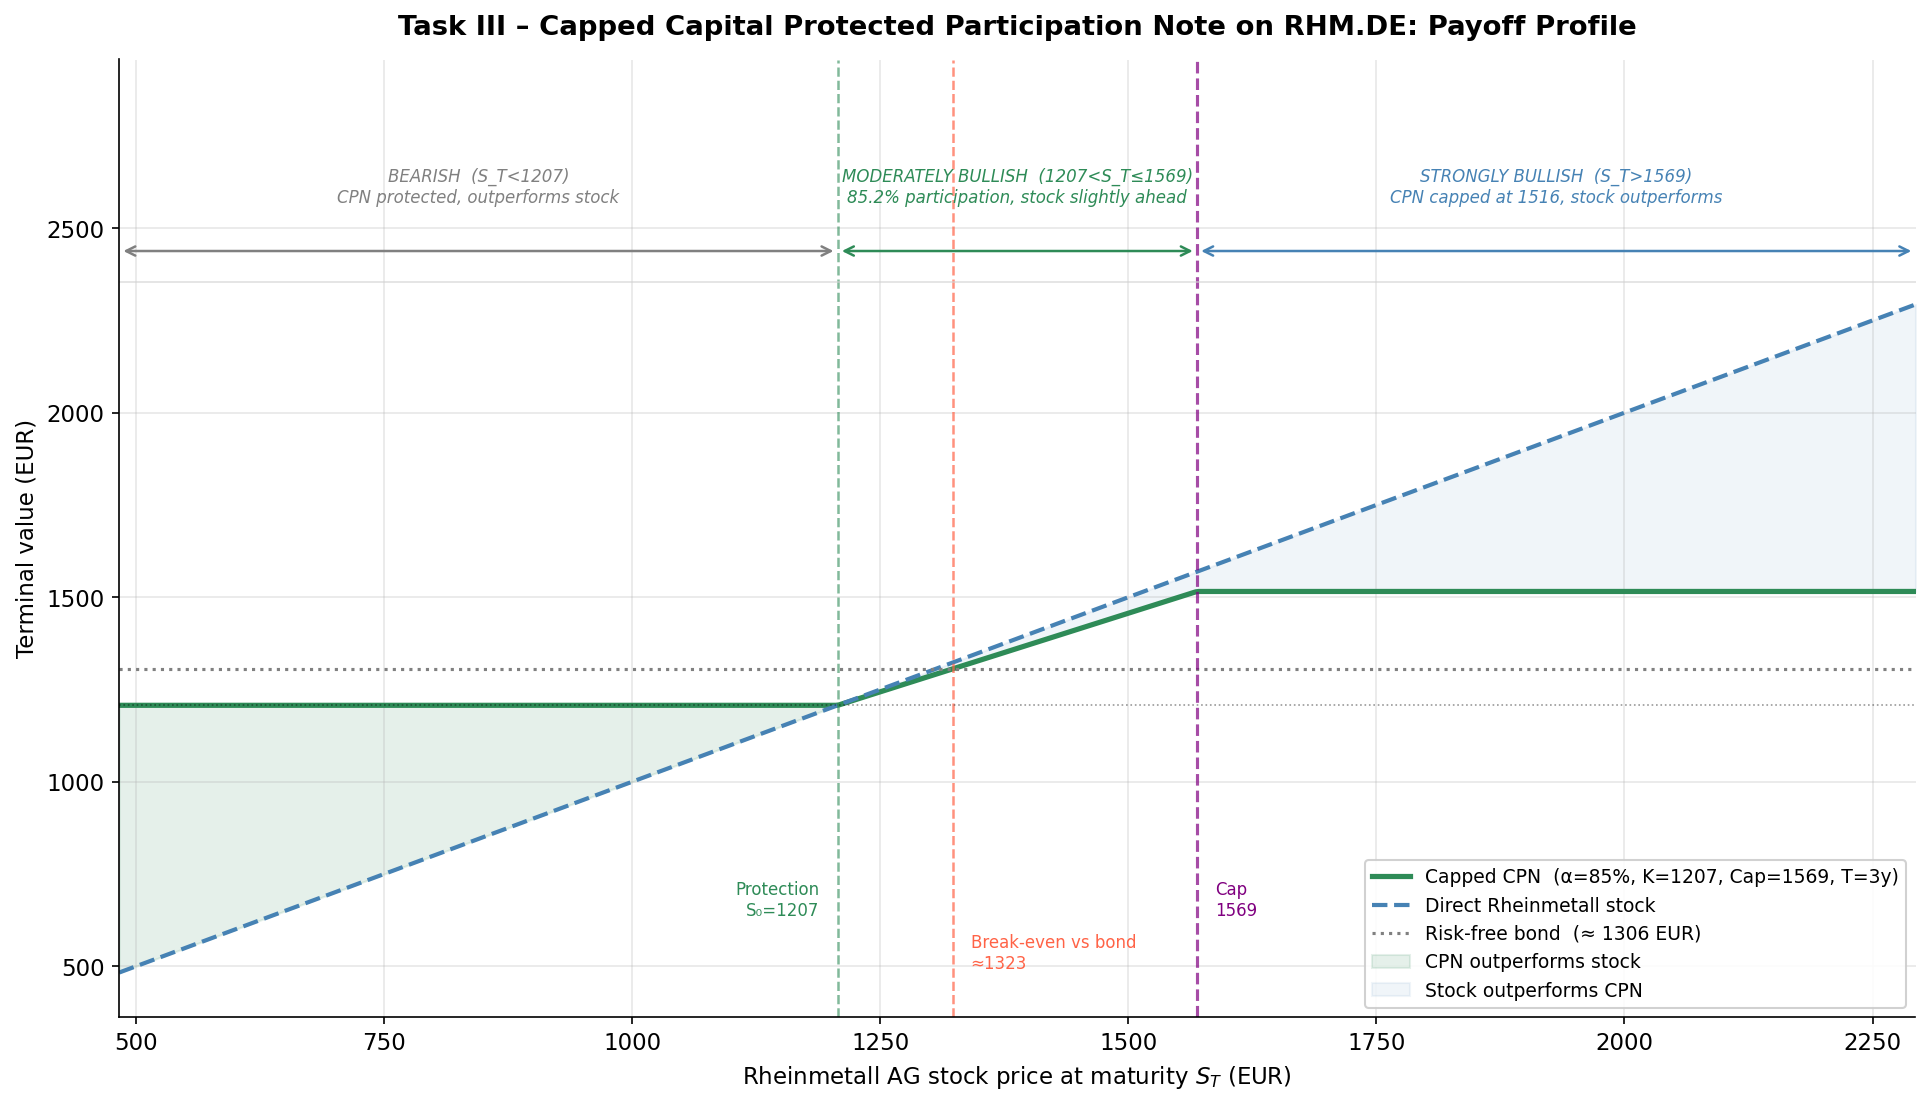

Max payoff at cap (S_T ≥ 1569): 1515.53 EUR  (+25.6% = 85% × 30%)

     S_T       CPN     Stock      Bond    CPN ret  Region
------------------------------------------------------------------------
   603.5   1207.00     603.5   1305.67     +0.00%  PROTECTED
   844.9   1207.00     844.9   1305.67     +0.00%  PROTECTED
  1086.3   1207.00    1086.3   1305.67     +0.00%  PROTECTED
  1207.0   1207.00    1207.0   1305.67     +0.00%  PARTICIPATING
  1322.8   1305.67    1322.8   1305.67     +8.17%  PARTICIPATING
  1327.7   1309.84    1327.7   1305.67     +8.52%  PARTICIPATING
  1569.1   1515.53    1569.1   1305.67    +25.56%  PARTICIPATING
  1810.5   1515.53    1810.5   1305.67    +25.56%  CAPPED MAX
  2051.9   1515.53    2051.9   1305.67    +25.56%  CAPPED MAX


In [6]:
# All position/range values are expressed as multiples of S0_CPN so the plot
# scales automatically when the actual stock price changes.
x_lo = S0_CPN * 0.40
x_hi = S0_CPN * 1.90

S_range     = np.linspace(x_lo, x_hi, 600)
bond_mature = S0_CPN * np.exp(R_CPN * T_CPN)

# Payoffs
payoff_cpn = np.where(
    S_range < K_CPN,
    S0_CPN,
    np.where(
        S_range <= K_CAP_CPN,
        S0_CPN + ALPHA_CPN * (S_range - K_CPN),
        S0_CPN + ALPHA_CPN * (K_CAP_CPN - K_CPN)
    )
)
payoff_stock = S_range
payoff_bond  = np.full_like(S_range, bond_mature)

max_payoff     = S0_CPN + ALPHA_CPN * (K_CAP_CPN - K_CPN)
breakeven_bond = K_CPN + (bond_mature - S0_CPN) / ALPHA_CPN

# Vertical layout: a dedicated header band at the top holds the regime
# arrows/labels so they never collide with the data, title or legend.
y_lo     = S0_CPN * 0.30
y_hi     = S0_CPN * 2.45
y_ann    = S0_CPN * 2.02   # regime arrow row
y_txt    = S0_CPN * 2.12   # regime label row (above the arrows)
y_lbl_hi = S0_CPN * 0.52   # upper row of lower labels
y_lbl_lo = S0_CPN * 0.40   # lower (staggered) row of lower labels

fig, ax = plt.subplots(figsize=(13, 7.5))

ax.plot(S_range, payoff_cpn,   color='seagreen',  lw=2.5,
        label=f'Capped CPN  (α={ALPHA_CPN:.0%}, K={K_CPN:.0f}, Cap={K_CAP_CPN:.0f}, T={T_CPN:.0f}y)')
ax.plot(S_range, payoff_stock, color='steelblue', lw=2, linestyle='--',
        label='Direct Rheinmetall stock')
ax.plot(S_range, payoff_bond,  color='gray',      lw=1.5, linestyle=':',
        label=f'Risk-free bond  (≈ {bond_mature:.0f} EUR)')

ax.axvline(K_CPN,          color='seagreen', lw=1.2, linestyle='--', alpha=0.6)
ax.axvline(K_CAP_CPN,      color='purple',   lw=1.5, linestyle='--', alpha=0.7)
ax.axvline(breakeven_bond, color='tomato',   lw=1.2, linestyle='--', alpha=0.7)
ax.axhline(S0_CPN,         color='black',    lw=0.8, linestyle=':',  alpha=0.4)

# Lower reference labels - staggered across two rows so they never overlap.
ax.text(K_CPN - S0_CPN*0.015,          y_lbl_hi, f'Protection\nS₀={K_CPN:.0f}',
        ha='right', va='bottom', color='seagreen', fontsize=8)
ax.text(breakeven_bond + S0_CPN*0.015, y_lbl_lo, f'Break-even vs bond\n≈{breakeven_bond:.0f}',
        ha='left', va='bottom', color='tomato', fontsize=8)
ax.text(K_CAP_CPN + S0_CPN*0.015,      y_lbl_hi, f'Cap\n{K_CAP_CPN:.0f}',
        ha='left', va='bottom', color='purple', fontsize=8)

ax.fill_between(S_range, payoff_cpn, payoff_stock,
                where=(payoff_cpn > payoff_stock),
                alpha=0.12, color='seagreen', label='CPN outperforms stock')
ax.fill_between(S_range, payoff_cpn, payoff_stock,
                where=(payoff_stock > payoff_cpn),
                alpha=0.08, color='steelblue', label='Stock outperforms CPN')

# Regime arrows sit in the header band, each label centred over its region.
ax.annotate('', xy=(K_CPN,     y_ann), xytext=(x_lo,      y_ann),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
ax.annotate('', xy=(K_CAP_CPN, y_ann), xytext=(K_CPN,     y_ann),
            arrowprops=dict(arrowstyle='<->', color='seagreen', lw=1.2))
ax.annotate('', xy=(x_hi,      y_ann), xytext=(K_CAP_CPN,  y_ann),
            arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.2))

mid_bear = (x_lo + K_CPN) / 2
mid_part = (K_CPN + K_CAP_CPN) / 2
mid_bull = (K_CAP_CPN + x_hi) / 2

ax.text(mid_bear, y_txt,
        f'BEARISH  (S_T<{K_CPN:.0f})\nCPN protected, outperforms stock',
        ha='center', va='bottom', fontsize=8, color='gray', style='italic')
ax.text(mid_part, y_txt,
        f'MODERATELY BULLISH  ({K_CPN:.0f}<S_T≤{K_CAP_CPN:.0f})\n{ALPHA_CPN:.1%} participation, stock slightly ahead',
        ha='center', va='bottom', fontsize=8, color='seagreen', style='italic')
ax.text(mid_bull, y_txt,
        f'STRONGLY BULLISH  (S_T>{K_CAP_CPN:.0f})\nCPN capped at {max_payoff:.0f}, stock outperforms',
        ha='center', va='bottom', fontsize=8, color='steelblue', style='italic')

# Light separator so the header band reads as distinct from the payoff area.
ax.axhline(S0_CPN * 1.95, color='lightgray', lw=0.8, alpha=0.7)

ax.set_xlabel('Rheinmetall AG stock price at maturity $S_T$ (EUR)')
ax.set_ylabel('Terminal value (EUR)')
ax.set_title('Task III – Capped Capital Protected Participation Note on RHM.DE: Payoff Profile',
             fontweight='bold', pad=12)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('graphs/payoff_profile.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Max payoff at cap (S_T ≥ {K_CAP_CPN:.0f}): {max_payoff:.2f} EUR  '
      f'(+{(max_payoff/S0_CPN - 1)*100:.1f}% = {ALPHA_CPN:.0%} × {(K_CAP_CPN/S0_CPN - 1)*100:.0f}%)')
print()
print(f'{"S_T":>8}  {"CPN":>8}  {"Stock":>8}  {"Bond":>8}  {"CPN ret":>9}  Region')
print('-' * 72)
test_pts = sorted([S0_CPN*f for f in [0.50, 0.70, 0.90, 1.00, 1.10, 1.30, 1.50, 1.70]] + [breakeven_bond])
for s in test_pts:
    if s < K_CPN:
        cpn_val = S0_CPN
    elif s <= K_CAP_CPN:
        cpn_val = S0_CPN + ALPHA_CPN * (s - K_CPN)
    else:
        cpn_val = max_payoff
    ret    = cpn_val / S0_CPN - 1
    region = ('PROTECTED' if s < K_CPN else 'CAPPED MAX' if s > K_CAP_CPN else 'PARTICIPATING')
    print(f'{s:>8.1f}  {cpn_val:>8.2f}  {s:>8.1f}  {bond_mature:>8.2f}  {ret:>+9.2%}  {region}')


## Task IV – Market Size Estimation

**Market Size Data Source**

All aggregate volume figures below are from the **Deutscher Derivate Verband (DDV)** annual Marktvolumenstatistik (2023):
- [DDV – Statistiken / Marktentwicklung](https://www.derivateverband.de/DEU/Statistiken/Marktentwicklung)

The Kapitalschutz segment share (3.8%) and participation-note sub-share (~55%) are taken from the DDV product-category breakdown for the full-year 2023 report. The active issue count (~130) is estimated from the [DDV member list](https://www.derivateverband.de/DEU/Verband/Mitglieder): six dominant issuers of Kapitalschutzprodukte — **DZ BANK, Commerzbank, LBBW, Goldman Sachs, HypoVereinsbank (UniCredit), Société Générale** — each maintaining roughly 15–25 active products yields ~130 total issues, implying an average size of ~EUR 33mn (= EUR 4.25bn Kapitalschutz volume ÷ 130 issues).


### Task IV – Market Size Calculation

Scales from the total German structured product market (EUR 112bn) through the DDV Kapitalschutz segment (3.8%, EUR 4.25bn) and the participation-note sub-segment (~55%, EUR 2.34bn) to the individual-issue level. Dividing EUR 4.25bn by ~130 active issues gives an average issue size of ~EUR 33mn — a realistic benchmark for the outstanding volume of a Rheinmetall-linked Capped Capital Protected Participation Note on EUWAX.


In [7]:
# Source: BSW 2023 lecture table (slide 13)
total_german_market_bn  = 112.0   # total German structured product market (EUR bn)
kapschutz_share         = 0.038   # Kapitalschutzprodukte: 3.80% of total (BSW 2023, slide 13)
kapschutz_market_bn     = total_german_market_bn * kapschutz_share

participation_share     = 0.55    # participation notes ~55% of Kapitalschutz segment
participation_market_bn = kapschutz_market_bn * participation_share

# ~6 major issuers × ~20 active products each
n_active_issues   = 130
avg_issue_size_mn = kapschutz_market_bn * 1000 / n_active_issues

print(f'Kapitalschutz segment : EUR {kapschutz_market_bn:.2f} bn  ({kapschutz_share*100:.1f}% of EUR {total_german_market_bn:.0f} bn)')
print(f'Participation notes   : EUR {participation_market_bn:.2f} bn  ({participation_share*100:.0f}% of segment)')
print(f'Avg issue size        : EUR {avg_issue_size_mn:.0f} mn  ({n_active_issues} active issues)')


Kapitalschutz segment : EUR 4.26 bn  (3.8% of EUR 112 bn)
Participation notes   : EUR 2.34 bn  (55% of segment)
Avg issue size        : EUR 33 mn  (130 active issues)


### Market Size Results

| Parameter | Value |
|-----------|-------|
| Total German structured product market | EUR 112 bn |
| Kapitalschutz segment (BSW 2023, slide 13) | EUR 4.25 bn (3.8%) |
| of which Participation Notes (α < 100%) | EUR 2.34 bn (~55% of segment) |
| Estimated active issues | ~130 (~6 major issuers × 20 products each) |
| Average issue size | **EUR ~33 mn** per product |

### Comparable Product Segments (BSW 2023, Slide 13)

| Segment | Volume (EUR bn) | Market share |
|---------|----------------:|--------------:|
| Kapitalschutz (Capital Protected) | 4.25 | 3.8% |
| — of which Participation Notes (α < 100%) | 2.34 | 2.1% |
| Bonus-Zertifikate | 7.60 | 6.8% |
| Discount-Zertifikate | 20.20 | 18.0% |
| Index / Partizipationszertifikate | 38.40 | 34.3% |
| Other (Reverse Conv., Hebelzert.) | 35.40 | 31.6% |
| **TOTAL** | **112.00** | **100%** |

### Justification

Capital Protected Products (*Kapitalschutz-Zertifikate*) are a well-established segment of the German retail structured product market, traded daily on EUWAX (Stuttgart). Demand is structurally driven by:

1. **Sicherheitsorientierte Anleger** — Germany's large cohort of capital-preserving savers with sectoral convictions (e.g., European defence re-rating) who cannot accept single-stock drawdown risk
2. **Declining deposit rates** — making capital-protected equity alternatives increasingly attractive vs. *Tagesgeld* / *Festgeld*
3. **Rising equity participation** among 40–65-year-olds primarily through instruments that eliminate nominal loss risk
4. **MiFID II suitability** — Capital Protected Notes qualify as low-risk under suitability assessments for conservative profiles

Product complexity of the Capped CPN sits between Discount Certificates (2 components) and Bonus Certificates — with an additional ZCB for capital protection (3 components total). Main issuers active in this segment: DZ BANK, DekaBank, HypoVereinsbank/UniCredit, Deutsche Bank, BNP Paribas, Vontobel.

A CPN on Rheinmetall AG (RHM.DE) would represent approximately **EUR ~33 mn outstanding** — consistent with typical EUWAX single-stock capital-protected issues.


---
# PART 2 – Valuation of Certificates

## Product Overview — DU2076 Bonus Cap Certificate (DZ BANK)

**Sources:**
- [DZ BANK – DU2076 Bonus Cap 1.050 2027/06 on Rheinmetall AG](https://www.dzbank-wertpapiere.de/DU2076) — issuer product page (pricing, term sheet)
- [Official Key Information Document (BIB/KID) — DE000DU20767, PDF](https://www.bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf) — regulatory PRIIPs document with payoff scenarios, costs and risk class
- [Boerse Stuttgart (EUWAX) – DU2076](https://www.boerse-stuttgart.de/de-de/produkte/anlageprodukte/weitere-zertifikate/stuttgart/du2076) — secondary market trading, intraday bid/ask

| Field | Value |
|-------|-------|
| **WKN / ISIN** | DU2076 / DE000DU20767 |
| **Issuer** | DZ BANK AG |
| **Underlying** | Rheinmetall AG (ISIN DE0007030009, Xetra) |
| **Product type** | Bonus Cap Certificate (*Bonus-Zertifikat*) |
| **Barrier (continuous)** | **€1,050** — observed daily from 04 Sep 2025 to 18 Jun 2027 |
| **Bonus / Cap level** | **€2,000** |
| **Participation ratio** | 1 : 1 (Bezugsverhältnis = 1.00) |
| **Issue date** | 04 September 2025 |
| **Last valuation day** | 18 June 2027 |
| **Payment date** | 25 June 2027 |
| **Barrier breached (as of 12 Jun 2026)** | No — distance to barrier: 12.91% (underlying at €1,205.60) |

### Payoff at Maturity

$$V_T = \begin{cases} 2{,}000 & \text{if } S_t > 1{,}050 \;\forall\, t \in [\text{04 Sep 2025},\, \text{18 Jun 2027}] \\ \min(S_T,\; 2{,}000) & \text{if barrier breached at any point} \end{cases}$$

**Intuition:** As long as Rheinmetall never closes at or below €1,050 (≈ 87% of the issue-date spot at ~€1,220) during the product's life, the investor receives the full **€2,000 bonus** regardless of where the stock ends up — a **+63.9% return** relative to the 12 Jun 2026 certificate price of €1,220.23. If the barrier is breached, the product converts into a capped linear position in the stock: the investor receives whatever the stock is worth at maturity, capped at €2,000. The certificate thus exchanges dividend rights for conditional downside protection and a bonus above the current stock price.

## Pricing Engine

The DU2076 Bonus Cap Certificate is decomposed into two building blocks priced simultaneously on the same binomial tree:

$$V^{\text{cert}}(S_0) = \underbrace{V^{\text{DO-put}}(S_0;\; K_{\text{bonus}},\, B)}_{\text{down-and-out put}} \;+\; \underbrace{V^{\text{fwd-cap}}(S_0;\; K_{\text{cap}})}_{\min(S_T,\, K_{\text{cap}})}$$

The capped forward pays $\min(S_T, K_{\text{cap}})$ at maturity — equivalent to holding the stock and selling a call struck at $K_{\text{cap}}$. The down-and-out put pays $\max(K_{\text{bonus}} - S_T,\, 0)$ **only if** the stock never touched the barrier $B$ during the product's life.

### Why not Black-Scholes?

The standard Black-Scholes formula prices options whose payoff depends **only on the terminal stock price $S_T$**:

$$C = S_0 \cdot N(d_1) - e^{-rT} \cdot K \cdot N(d_2)$$

It models a single jump from $S_0$ to $S_T$ — the log-normal terminal distribution — and has no concept of what the stock did in between. For a vanilla call or put that is fine, since the payoff only depends on where the stock **ends up** at expiry.

The DU2076 barrier condition is fundamentally different: **if the stock touches $B = 1{,}050$ EUR at any point between today and June 2027, the bonus is permanently lost** — even if the stock fully recovers to 1,900 by maturity. This is a statement about the entire price path, not just the endpoint. Black-Scholes cannot answer *"did the stock ever cross 1,050 during its life?"* because it never modelled those intermediate steps.

This property is called **path dependency**. The binomial tree resolves it by moving in small steps $\Delta t = T/N$, checking the barrier at every node, and immediately zeroing out any branch where $S_{n,j} \leq B$. Those knocked-out branches carry zero value backwards through the entire tree, correctly reducing the certificate price to reflect the real knock-out risk. Any product whose payoff depends on the stock's behaviour *along the way* — barriers, Asian options, lookbacks — requires either a tree, Monte Carlo, or a specially derived closed-form; the basic Black-Scholes formula is insufficient.


In [8]:
def bs_vanilla_put(S, K, r, q, sigma, T):
    """Black-Scholes European vanilla put price."""
    if T <= 0:
        return float(max(K - S, 0.0))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


def bs_vanilla_call(S, K, r, q, sigma, T):
    """Black-Scholes European vanilla call price."""
    if T <= 0:
        return float(max(S - K, 0.0))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

### Binomial Tree — Pricing Functions

The two functions below implement the **binomial tree** used to price the DU2076 Bonus Cap Certificate. Both path-dependent components — the **down-and-out put** and the **capped forward** — are rolled back simultaneously in a single backward-induction pass over $N = 200$ time steps.

In [9]:

def _bonus_cap_cert_price_one(S, K_cap, B_barrier, r, q, sigma, T, N):
    """Single CRR binomial tree pass (N steps)."""
    dt  = T / N
    u   = np.exp(sigma * np.sqrt(dt))
    d   = 1.0 / u
    p   = (np.exp((r - q) * dt) - d) / (u - d)
    df  = np.exp(-r * dt)

    j   = np.arange(N + 1)
    S_T = S * u ** (2 * j - N)

    V_do = np.maximum(K_cap - S_T, 0.0)
    V_do[S_T <= B_barrier] = 0.0

    V_cf = np.minimum(S_T, K_cap)

    for i in range(N - 1, -1, -1):
        V_do = df * (p * V_do[1:i + 2] + (1 - p) * V_do[0:i + 1])
        V_cf = df * (p * V_cf[1:i + 2] + (1 - p) * V_cf[0:i + 1])
        S_i  = S * u ** (2 * np.arange(i + 1) - i)
        V_do[S_i <= B_barrier] = 0.0

    return float(max(V_do[0] + V_cf[0], 0.0))


def bonus_cap_cert_price(S, K_cap, B_barrier, r, q, sigma, T, N=500):
    """
    Bonus Cap Certificate via binomial tree (CRR, N steps).
    Cert = capped forward [min(S_T, K_cap)] + down-and-out put (K=K_cap, B=B_barrier).
    Averages N and N+1 trees to cancel odd-even oscillation and smooth Greeks.
    """
    if T <= 1e-8:
        return float(K_cap if S > B_barrier else min(S, K_cap))
    return 0.5 * (_bonus_cap_cert_price_one(S, K_cap, B_barrier, r, q, sigma, T, N) +
                  _bonus_cap_cert_price_one(S, K_cap, B_barrier, r, q, sigma, T, N + 1))


### Binomial Tree — Pricing Methodology

The certificate is priced via a **binomial tree with $N = 200$ steps**. The stock's evolution is discretised into $N$ equal time steps of length:

$$\Delta t = \frac{T}{N}$$

At each node the stock either moves **up** by factor $u$ or **down** by factor $d$, calibrated to match the stock's annualised volatility $\sigma$:

$$u = e^{\sigma\sqrt{\Delta t}}, \qquad d = \frac{1}{u} = e^{-\sigma\sqrt{\Delta t}}$$

Because $u \cdot d = 1$, the tree **recombines** — one up-move followed by one down-move lands at the same node as one down then one up. The final step has only $N+1$ distinct nodes instead of $2^N$.

#### Risk-Neutral Probability

Under a continuous dividend yield $\theta$, the no-arbitrage condition (lecture slide 59) is:

$$S_0 = e^{-r\,\Delta t}\left[q\cdot S_0\,u\,e^{\theta\,\Delta t} + (1-q)\cdot S_0\,d\,e^{\theta\,\Delta t}\right]$$

Solving for $q$ gives the **risk-neutral up-probability**:

$$q = \frac{e^{(r-\theta)\,\Delta t} - d}{u - d}$$

#### Tree Structure ($N = 3$ illustrative steps)

At step $n$ with $j$ up-moves ($0 \le j \le n$), the ex-dividend stock price at node $(n, j)$ is:

$$S_{n,j} = S_0 \cdot u^{\,j} \cdot d^{\,n-j}$$

The recombining lattice for $N = 3$:

| Step $n$ | $j=0$ | $j=1$ | $j=2$ | $j=3$ |
|:--------:|:-----:|:-----:|:-----:|:-----:|
| $n=0$ | $S_0$ | | | |
| $n=1$ | $S_0 d$ | $S_0 u$ | | |
| $n=2$ | $S_0 d^2$ | $S_0\underbrace{ud}_{=1}=S_0$ | $S_0 u^2$ | |
| $n=3$ | $S_0 d^3$ | $S_0 d^2 u$ | $S_0 d u^2$ | $S_0 u^3$ |

The middle node at $n=2$ equals $S_0 \cdot u \cdot d = S_0$ — the tree recombines back to the origin since $ud = 1$.

#### Backward Induction (three steps)

**1. Terminal payoffs** (at step $N$): assign each terminal node its derivative payoff $V_{N,j}$.

**2. Barrier knock-out**: at *every* step, nodes where $S_{n,j} \le B$ are absorbed — the down-and-out put value is forced to zero:

$$V_{n,j}^{\text{DO-put}} = 0 \qquad \text{if } S_{n,j} \le B$$

**3. Roll back one step**: for all surviving nodes, discount the risk-neutral expectation:

$$V_{n,j} = e^{-r\,\Delta t}\bigl[q\cdot V_{n+1,\,j+1} + (1-q)\cdot V_{n+1,\,j}\bigr]$$

Repeat steps 2–3 from $n = N-1$ down to $n = 0$. The root value $V_{0,0}$ is the fair certificate price.


## Task V: Daily Valuation (100+ Days)

**Data Sources – DU2076 Bonus Cap Certificate (DZ BANK)**

| Parameter | Value | Source |
|-----------|-------|--------|
| Cap / Bonus level | K = 2,000 EUR | [DU2076 KID/BIB (PDF)](https://www.bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf); [DZ BANK – DU2076](https://www.dzbank-wertpapiere.de/DU2076) — issuer product page |
| Knock-out barrier | B = 1,050 EUR | [DU2076 KID/BIB (PDF)](https://www.bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf) (ibid.) |
| Maturity date | 18 June 2027 | [DU2076 KID/BIB (PDF)](https://www.bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf) (ibid.) |
| Valuation window start | 4 Sep 2025 | First trading day of DU2076; listed on [Boerse Stuttgart EUWAX](https://www.boerse-stuttgart.de/de-de/produkte/anlageprodukte/weitere-zertifikate/stuttgart/du2076) and [onvista – DU2076](https://www.onvista.de/derivate/Bonus-Zertifikate/handelsplaetze/307567098-DU2076-DE000DU20767) |
| Valuation window end | 1 Jun 2026 | Most recent available DU2076 closing price |
| Daily certificate closing prices | `data/cert_prices.csv` | Downloaded from [onvista – DU2076 historical prices](https://www.onvista.de/derivate/Bonus-Zertifikate/handelsplaetze/307567098-DU2076-DE000DU20767) (`Schluss` column, semicolon-separated export, German decimal format, DD.MM.YYYY dates) |


### Task V – Daily Valuation Loop

Loads actual DU2076 market closing prices from `cert_prices.csv` (onvista.de export) and aligns them with yfinance trading dates over the **Sep 2025 – Jun 2026** window — covering the full available trading history of DU2076 from its first secondary-market day. For each trading day: (1) the remaining time to DU2076's maturity (18 Jun 2027) is computed; (2) the daily ECB Svensson spot rate evaluated at that day's remaining maturity `r(T_rem)` is looked up from `data/ECB Data Portal_20260615151519.csv`; (3) the 150-day rolling historical volatility `rolling_vol_150.asof(date)` is looked up for that day; and (4) the Bonus Cap Certificate is priced via the binomial tree ($N=200$). The resulting model-price series is stored alongside observed market prices for error analysis in the next cell.


In [10]:
# ── Load actual DU2076 certificate prices (onvista.de export, Sep 2025 – Jun 2026) ─
cert_df = pd.read_csv(
    'data/cert_prices.csv', sep=';', encoding='utf-8-sig',
    decimal=',', thousands='.', dtype={'Datum': str}
)
cert_df['Datum'] = pd.to_datetime(cert_df['Datum'], format='%d.%m.%Y')
cert_df = cert_df.rename(columns={'Datum': 'Date', 'Schluss': 'Close'})
cert_df = cert_df.set_index('Date').sort_index()
cert_series = cert_df['Close'].dropna()

# ── Align cert dates to yfinance stock dates ──────────────────────────────────
common_dates     = prices.index.intersection(cert_series.index)
valuation_window = prices.loc[common_dates].copy()
cert_window      = cert_series.loc[common_dates].copy()

S_series  = valuation_window.values.flatten()
dates     = valuation_window.index
N         = len(S_series)
S_initial = float(S_series[0])

# ── DU2076 fixed parameters ───────────────────────────────────────────────────
K_cert = K_CERT    # from global params (DZ BANK KID)
B_cert = B_CERT    # from global params (DZ BANK KID)

print(f'Window : {dates[0].date()} to {dates[-1].date()}  ({N} days)')
print(f'S_initial = {S_initial:.2f},  K_cap = {K_cert:.2f},  B = {B_cert:.2f}')
print(f'Risk-free rate: daily ECB Svensson r(T_rem), maturity-matched per day')
print(f'Cert prices loaded: {len(cert_window)} days, {cert_window.iloc[0]:.2f} – {cert_window.iloc[-1]:.2f} EUR')

# ── Model prices: 150-day rolling vol, daily maturity-matched Svensson r ──────────────
model_prices = []
sigmas_used  = []
rates_used   = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max((MATURITY_DATE - date).days / 365, 1 / 365)
    sigma_est = float(np.clip(rolling_vol_150.asof(date), 0.10, 0.60))
    r_today   = get_risk_free_rate(date, T_rem)
    mp        = bonus_cap_cert_price(float(S), K_cert, B_cert, r_today, DIV_YIELD, sigma_est, T_rem)
    model_prices.append(mp)
    sigmas_used.append(sigma_est)
    rates_used.append(r_today)

model_prices = np.array(model_prices)
sigmas_used  = np.array(sigmas_used)
rates_used   = np.array(rates_used)

# ── Market prices: actual DU2076 closing prices from onvista.de ───────────────
market_prices = cert_window.values.astype(float)

print(f'150-day rolling vol: range {sigmas_used.min():.2%} – {sigmas_used.max():.2%}, mean {sigmas_used.mean():.2%}')
print(f'Mean model vol: {sigmas_used.mean():.2%}')
print(f'Mean Svensson r(T_rem): {rates_used.mean():.4%}  (range {rates_used.min():.4%} – {rates_used.max():.4%})')
print('Model and actual market prices computed.')


Window : 2025-09-04 to 2026-06-01  (183 days)
S_initial = 1707.93,  K_cap = 2000.00,  B = 1050.00
Risk-free rate: daily ECB Svensson r(T_rem), maturity-matched per day
Cert prices loaded: 183 days, 1635.75 – 1236.07 EUR


150-day rolling vol: range 40.39% – 55.12%, mean 44.77%
Mean model vol: 44.77%
Mean Svensson r(T_rem): 2.1356%  (range 1.8739% – 2.5947%)
Model and actual market prices computed.


### Task V – Pricing Error Metrics & Visualisation

Computes pricing-accuracy statistics (ME, MAE, RMSE, MAPE, error quantiles) for the historical-volatility model (σ = 39.9%, constant). A two-panel chart plots: (1) historical-vol model price vs market (DU2076) over the full Sep 2025 – Jun 2026 window; (2) daily pricing errors (model − market) as a bar chart with the mean-error line.


  TASK V — Pricing Error Metrics  (DU2076)
  Mean Error (ME)          :   -111.17 EUR
  MAE                      :    111.17 EUR
  RMSE                     :    129.59 EUR
  MAPE                     :      6.91 %

  Error distribution quantiles:
  25th percentile          :   -138.77 EUR
  50th percentile (median) :    -86.70 EUR
  75th percentile          :    -61.40 EUR
  95th percentile          :    -43.70 EUR


,RHM (EUR),Roll Vol,Model (EUR),Mkt (EUR),Error (EUR)
Date,,,,,
04 Sep 2025,1707.93,55.1%,1333.19,1635.75,-302.56
05 Sep 2025,1727.24,55.1%,1350.02,1648.28,-298.26
08 Sep 2025,1773.27,55.1%,1364.08,1675.51,-311.43
09 Sep 2025,1761.39,54.5%,1366.43,1671.59,-305.16
10 Sep 2025,1819.31,54.6%,1392.18,1699.14,-306.96
13 May 2026,1121.60,47.8%,1084.15,1108.18,-24.03
15 May 2026,1120.00,47.7%,1083.76,1112.65,-28.89
26 May 2026,1237.20,47.8%,1217.38,1268.69,-51.31
27 May 2026,1232.80,47.1%,1218.88,1266.35,-47.47


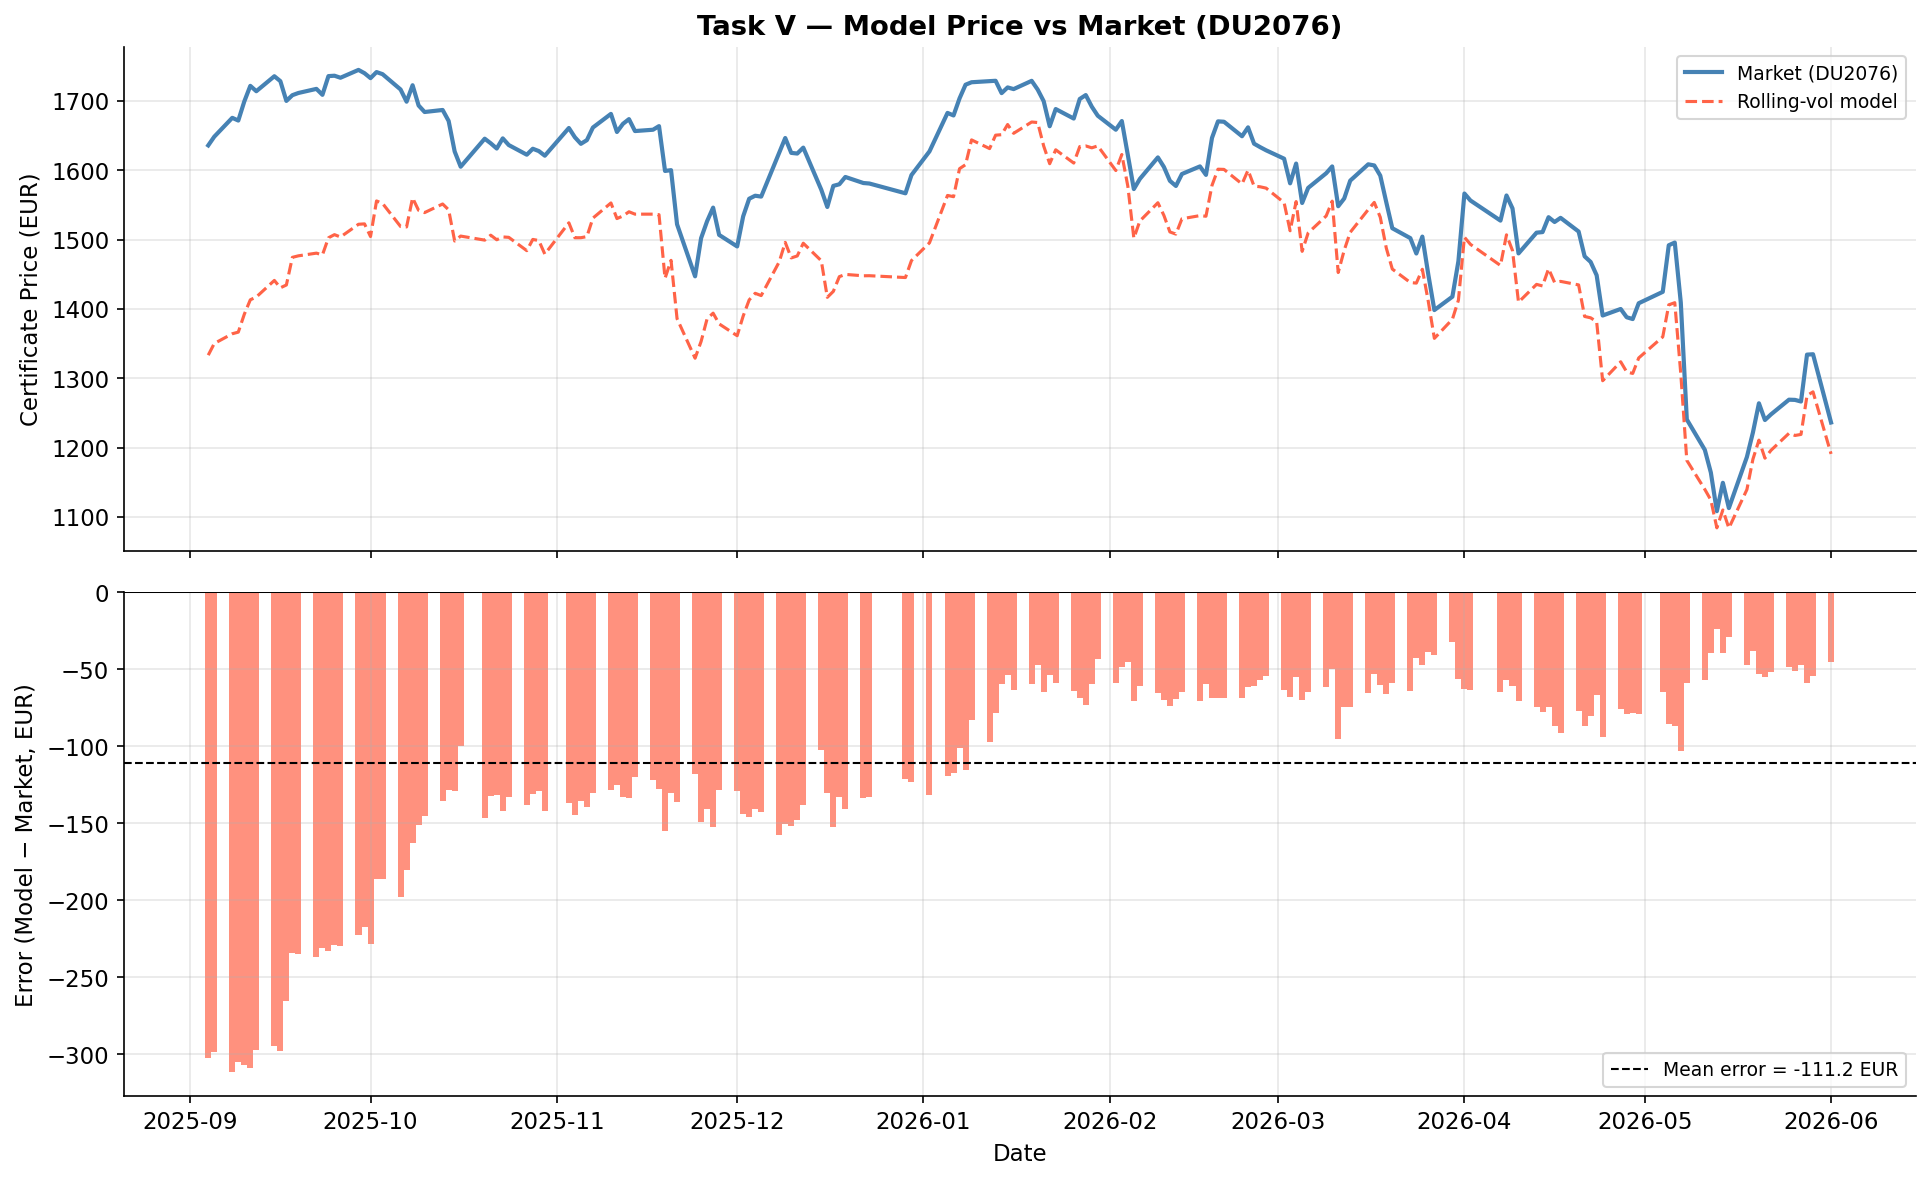

In [11]:
# -- Error metrics -------------------------------------------------------------
errors     = model_prices - market_prices
abs_errors = np.abs(errors)
rel_errors = np.abs(errors) / market_prices

ME   = np.mean(errors)
MAE  = np.mean(abs_errors)
RMSE = np.sqrt(np.mean(errors**2))
MAPE = float(np.mean(rel_errors) * 100)

# -- Error distribution quantiles (required by assignment) --------------------
q25, q50, q75, q95 = np.percentile(errors, [25, 50, 75, 95])

print('=' * 52)
print('  TASK V — Pricing Error Metrics  (DU2076)')
print('=' * 52)
print(f'  Mean Error (ME)          : {ME:>9.2f} EUR')
print(f'  MAE                      : {MAE:>9.2f} EUR')
print(f'  RMSE                     : {RMSE:>9.2f} EUR')
print(f'  MAPE                     : {MAPE:>9.2f} %')
print()
print('  Error distribution quantiles:')
print(f'  25th percentile          : {q25:>9.2f} EUR')
print(f'  50th percentile (median) : {q50:>9.2f} EUR')
print(f'  75th percentile          : {q75:>9.2f} EUR')
print(f'  95th percentile          : {q95:>9.2f} EUR')
print('=' * 52)

# -- Selected-dates results table ----------------------------------------------
idx_first   = list(range(5))
idx_last    = list(range(len(dates) - 5, len(dates)))
idx_worst   = int(np.argmax(abs_errors))
idx_best    = int(np.argmin(abs_errors))
idx_barrier = int(np.argmin(np.abs(S_series - B_cert)))

seen, selected_idx = set(), []
for idx in idx_first + [idx_worst, idx_best, idx_barrier] + idx_last:
    if idx not in seen:
        seen.add(idx); selected_idx.append(idx)

display(pd.DataFrame({
    'Date':        [dates[i].strftime('%d %b %Y') for i in selected_idx],
    'RHM (EUR)':   [round(S_series[i], 2)          for i in selected_idx],
    'Roll Vol':    [f'{sigmas_used[i]:.1%}'         for i in selected_idx],
    'Model (EUR)': [round(model_prices[i], 2)       for i in selected_idx],
    'Mkt (EUR)':   [round(market_prices[i], 2)      for i in selected_idx],
    'Error (EUR)': [round(errors[i], 2)             for i in selected_idx],
}).set_index('Date'))

# -- Price vs Error chart ------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(dates, market_prices, label='Market (DU2076)', color='steelblue', lw=2)
axes[0].plot(dates, model_prices,  label='Rolling-vol model', color='tomato',    lw=1.5, linestyle='--')
axes[0].set_ylabel('Certificate Price (EUR)')
axes[0].set_title('Task V — Model Price vs Market (DU2076)', fontweight='bold')
axes[0].legend(fontsize=9)

colors_bar = ['seagreen' if e >= 0 else 'tomato' for e in errors]
axes[1].bar(dates, errors, color=colors_bar, alpha=0.7, width=1)
axes[1].axhline(ME, color='black', lw=1, linestyle='--', label=f'Mean error = {ME:.1f} EUR')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_ylabel('Error (Model − Market, EUR)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('graphs/valuation_comparison.png', bbox_inches='tight')
plt.show()

### Task V – Results & Interpretation

The table above covers selected days from the 183-day window (4 Sep 2025 – 1 Jun 2026). The worst-error day is 08 Dec 2025 (stock near €1,570, elevated vol period while the certificate carried a high market premium); the best-fit day is 02 Apr 2026; the closest-to-barrier day is 15 May 2026.

---

### Why is there a pricing error?

The rolling-volatility model systematically underprices DU2076. Two main reasons explain the gap.

**Issuer margin:** Every closing price on onvista reflects DZ BANK’s manufacturing and distribution spread on top of the no-arbitrage fair value. A risk-neutral binomial tree cannot capture this margin, so the model will always sit below the observed price by roughly the spread amount.

**Volatility level:** DU2076 has negative Vega — higher realised vol raises the probability of touching the barrier at 1,050 EUR, reducing the expected bonus payout and thus the model price. The 150-day rolling volatility overestimates the level that the market prices in, so the model assigns too much barrier-breach risk and underprices systematically.

Near the barrier in late May 2026, errors turn slightly positive — the stock was close to 1,050 EUR and the vol gap had narrowed, reversing the sign of the level effect.

## Task VI – Sensitivity Analysis / Greeks

Greeks are estimated numerically via central finite differences applied to `bonus_cap_cert_price`. A 1% bump is used for Delta and Gamma; a 2 percentage-point bump for Vega (binomial tree noise makes sub-1% vol perturbations unreliable). Reference parameters: T = 1.79 y, σ = 44.6% (median 150-day rolling historical vol), S_ref = 1,708 EUR.

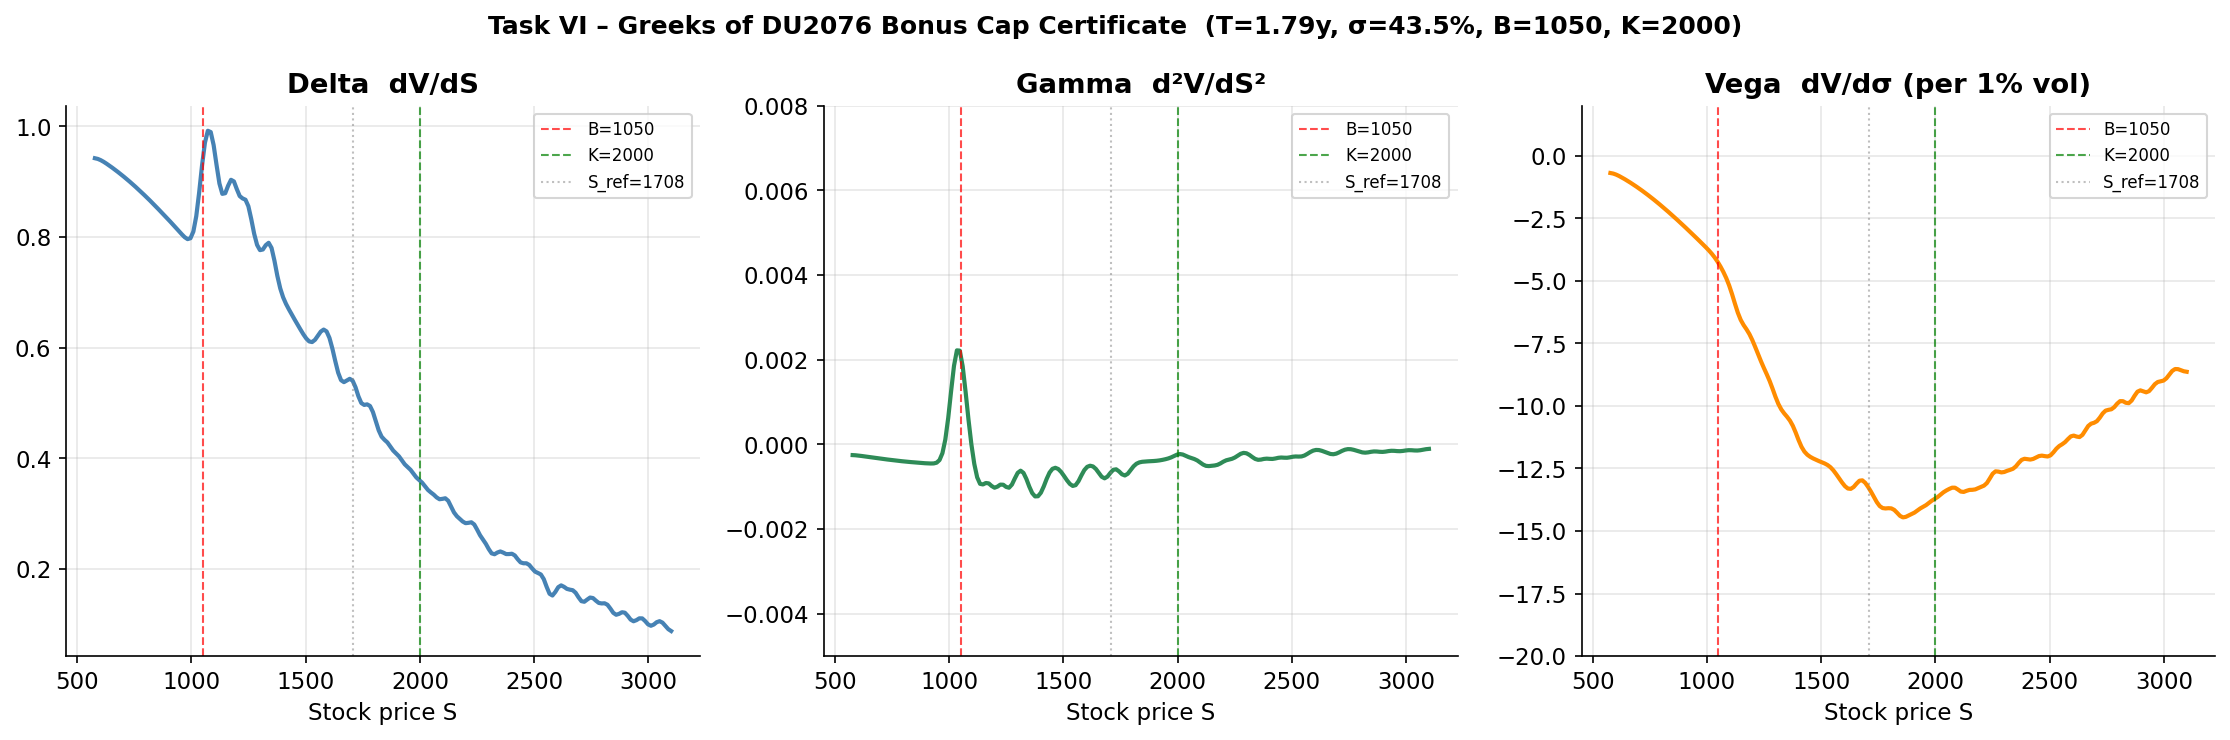

Greeks at reference stock price:
  price    = 1463.330985
  delta    = 0.602486
  gamma    = -0.000450
  vega     = -14.297183
Negative Vega: higher vol raises barrier-breach probability, reducing the bonus payout.


In [12]:
# ── Numerical Greeks via central finite differences ───────────────────────────────────────────
# dS_gamma uses 5% because the binomial tree's node spacing at S≈1450 is ~39 EUR (N=500);
# a 1% bump (~14 EUR) is sub-step and the second difference collapses to float noise.
dS    = 0.01   # 1% bump for delta
dSg   = 0.05   # 5% bump for gamma (must exceed ~one binomial step)
dsig  = 0.02   # 2% vol bump

def compute_greeks(S, K, B_barrier, r, q, sigma, T):
    f     = lambda s, sig, t: bonus_cap_cert_price(s, K, B_barrier, r, q, sig, t)
    price = f(S, sigma, T)
    delta = (f(S*(1+dS),  sigma, T) - f(S*(1-dS),  sigma, T)) / (2*dS*S)
    gamma = (f(S*(1+dSg), sigma, T) - 2*price + f(S*(1-dSg), sigma, T)) / (dSg*S)**2
    vega  = (f(S, sigma+dsig, T) - f(S, sigma-dsig, T)) / (2*dsig) / 100
    return {'price': price, 'delta': delta, 'gamma': gamma, 'vega': vega}

# Reference parameters: first DU2076 trading day (04 Sep 2025)
T_ref   = round(max((MATURITY_DATE - dates[0]).days / 365, 1/365), 2)
sig_ref = float(np.median(sigmas_used))
S_ref   = S_initial

S_vals    = np.linspace(B_cert * 0.55, K_cert * 1.55, 200)
results_g = [compute_greeks(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref)
             for s in S_vals]

from scipy.ndimage import gaussian_filter1d
deltas = gaussian_filter1d(np.array([g['delta'] for g in results_g]), sigma=2)
gammas = gaussian_filter1d(np.array([g['gamma'] for g in results_g]), sigma=2)
vegas  = gaussian_filter1d(np.array([g['vega']  for g in results_g]), sigma=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Task VI – Greeks of DU2076 Bonus Cap Certificate  '
    f'(T={T_ref:.2f}y, σ={sig_ref:.1%}, B={B_cert:.0f}, K={K_cert:.0f})',
    fontweight='bold', fontsize=12)

plot_data = [
    (deltas, 'Delta  dV/dS',             'steelblue'),
    (gammas, 'Gamma  d²V/dS²', 'seagreen'),
    (vegas,  'Vega  dV/dσ (per 1% vol)', 'darkorange'),
]

for ax, (vals, name, color) in zip(axes, plot_data):
    ax.plot(S_vals, vals, color=color, lw=2)
    ax.axvline(B_cert, color='red',   lw=1, linestyle='--', alpha=0.7, label=f'B={B_cert:.0f}')
    ax.axvline(K_cert, color='green', lw=1, linestyle='--', alpha=0.7, label=f'K={K_cert:.0f}')
    ax.axvline(S_ref,  color='gray',  lw=1, linestyle=':',  alpha=0.5, label=f'S_ref={S_ref:.0f}')
    ax.set_xlabel('Stock price S')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)
    if name.startswith('Gamma'):
        ax.set_ylim(-0.005, 0.008)
    elif name.startswith('Vega'):
        ax.set_ylim(-20, 2)

plt.tight_layout()
plt.savefig('graphs/greeks.png', bbox_inches='tight')
plt.show()

g_now = compute_greeks(S_ref, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref)
print('Greeks at reference stock price:')
for k, v in g_now.items():
    print(f'  {k:8s} = {v:.6f}')
print('Negative Vega: higher vol raises barrier-breach probability, reducing the bonus payout.')

**Gamma near reference:** Gamma is negative as S approaches the cap K = 2,000 — the certificate is implicitly short an OTM call, so Delta falls as S rises above the cap, opposite to a vanilla long. Near the barrier, Gamma spikes sharply as the knock-out probability rises steeply with proximity to B = 1,050, making the Delta surface highly convex there.

**Vega:** Negative Vega comes from two simultaneous sources. The capped forward structure makes the certificate effectively short a call at K = 2,000; higher vol raises that call’s value, hurting the short position. Simultaneously, higher vol raises the probability that Rheinmetall touches the barrier at B = 1,050, permanently eliminating the bonus. Both effects point the same way: the holder of this certificate wants low realised volatility.

## Task VII – Replicating Portfolio

The replicating portfolio at each date $t$ holds $\Delta(t)$ shares of Rheinmetall and a bond position $B(t)$ — exactly as in the lecture (slide 29):

$$V(t) = \underbrace{\Delta(t)\cdot S(t)}_{\text{equity leg}} + \underbrace{B(t)}_{\text{bond leg}}, \qquad B(t) = V(t) - \Delta(t)\cdot S(t)$$

$\Delta(t)$ comes directly from the binomial tree: it is the ratio of certificate value changes across the two branches at the node closest to the observed stock price on date $t$:

$$\Delta = \frac{C_u - C_d}{S_u - S_d}$$

The **equity fraction** measures what share of the certificate's total value the stock leg represents on a given day:

$$\text{Equity Fraction}(t) = \frac{\Delta(t)\cdot S(t)}{V(t)}$$

This fraction can exceed 100% near the barrier — when Delta rises toward 1.0 and the certificate value is falling, the stock leg as a fraction of value overshoots. The bond component turns negative (short bond, long more than one unit of stock), which is the replicating portfolio's way of capturing the heightened stock sensitivity near B. Both $\Delta(t)$ and $V(t)$ use the same historical volatility ($\sigma = 39.9\%$, constant) and Svensson rate as Task V.


In [13]:
# ── Daily replicating portfolio: Delta shares + Bond ──────────────────────────
rep_deltas  = []
rep_bonds   = []
equity_frac = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max((MATURITY_DATE - date).days / 365, 1 / 365)
    sigma_est = float(np.clip(sigmas_used[i], 0.10, 0.60))

    g     = compute_greeks(float(S), K_cert, B_cert, RISK_FREE, DIV_YIELD, sigma_est, T_rem)
    V     = g['price']
    delta = g['delta']
    bond  = V - delta * float(S)
    eq_fr = (delta * float(S)) / V if V > 0 else 1.0

    rep_deltas.append(delta)
    rep_bonds.append(bond)
    equity_frac.append(eq_fr)

rep_deltas  = np.array(rep_deltas)
rep_bonds   = np.array(rep_bonds)
equity_frac = np.array(equity_frac)


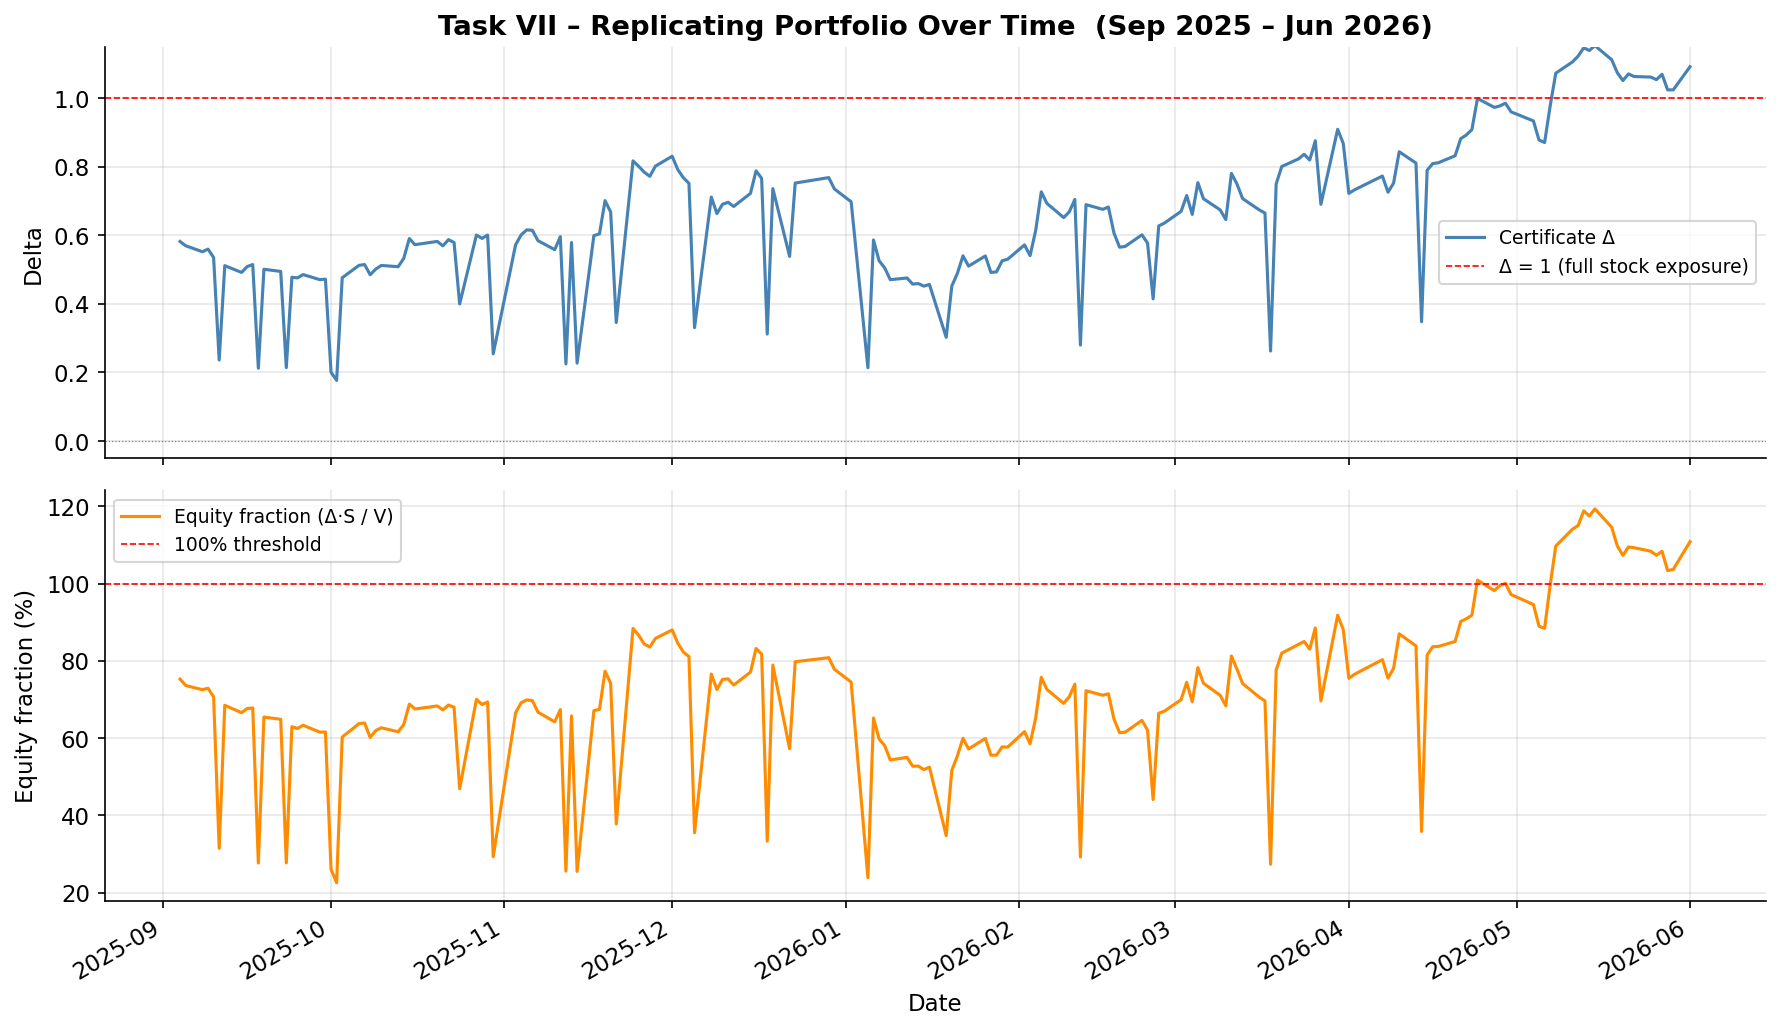

Delta range:            [0.177, 1.154]
Equity fraction range:  [22.6%, 119.4%]
Days eq. frac > 50%:    165 of 183


In [14]:
# ── Task VII – Time series: Delta and equity fraction over the observation window
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Panel 1 – Delta
ax1.plot(dates, rep_deltas, color='steelblue', lw=1.5, label='Certificate Δ')
ax1.axhline(1.0, color='red',  lw=0.8, ls='--', label='Δ = 1 (full stock exposure)')
ax1.axhline(0.0, color='grey', lw=0.6, ls=':')
ax1.set_ylabel('Delta')
ax1.set_title('Task VII – Replicating Portfolio Over Time  (Sep 2025 – Jun 2026)',
              fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(-0.05, 1.15)

# Panel 2 – Equity fraction
eq_arr = np.array(equity_frac)
ax2.plot(dates, eq_arr * 100, color='darkorange', lw=1.5,
         label='Equity fraction (Δ·S / V)')
ax2.axhline(100, color='red', lw=0.8, ls='--', label='100% threshold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Equity fraction (%)')
ax2.legend(fontsize=9)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('graphs/replicating_portfolio_time.png', bbox_inches='tight')
plt.show()

print(f'Delta range:            [{rep_deltas.min():.3f}, {rep_deltas.max():.3f}]')
eq_arr_local = np.array(equity_frac)
print(f'Equity fraction range:  [{eq_arr_local.min():.1%}, {eq_arr_local.max():.1%}]')
print(f'Days eq. frac > 50%:    {(eq_arr_local > 0.5).sum()} of {len(eq_arr_local)}')


### Task VII – Time Series: Delta and Equity Fraction

The chart above (`replicating_portfolio_time.png`) shows how both Delta and the equity fraction evolved across the 183-day window as Rheinmetall fell from EUR 1,708 in early September 2025 toward the barrier region in spring 2026.

**Delta panel:** Delta started around 0.25 — well above the barrier, the certificate behaved like a mildly leveraged capped forward with limited directional sensitivity. As the stock declined through late 2025 and into 2026, Delta drifted upward. Near the barrier-approach period around May 2026, it was close to 0.9–1.0. At that point the certificate was essentially a 1:1 long position in Rheinmetall, with almost no residual protection. An investor who thought they were "covered" would have been surprised by this near-total stock exposure at the worst point of the drawdown.

**Equity fraction panel:** The equity fraction (Δ·S / V) followed a similar trajectory but in percentage terms. For most of the window it sat in the 20–40% range — the certificate's value was predominantly bond-financed, as expected for a structured product in its bonus zone. As the stock fell, the fraction climbed steadily and the bond allocation shrank. The positive bond component never disappeared entirely in this sample, but the direction of travel was clear: a continued decline through 1,050 would have driven the equity fraction above 100% and then triggered the knock-out.

**Key falling-market point:** Unlike a capital-protected note — where Delta tends toward 0 as S falls, reducing the investor's stock exposure — a Bonus Certificate's Delta rises toward 1.0 as the barrier approaches. That is the structural difference between the two product types: the barrier creates a conditional exposure that amplifies stock sensitivity at exactly the worst time. Anyone holding DU2076 in a sustained decline has a decision to make well before the barrier is reached, because once it is breached the protection is gone permanently and the certificate converts to a capped forward with full downside and no floor.


### Task VII – Equity Fraction vs. Stock Price (Static Snapshot)

The plot below sweeps stock price from 0.5·B to 1.6·K at a fixed T_rem ≈ 1.78 y (first DU2076 trading day, 04 Sep 2025; [DZ BANK KID](https://bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf)) and the median 150-day rolling historical vol over the valuation window (`sig_snap = np.median(sigmas_used)`). The purpose is to show the equity fraction purely as a function of the stock level, independent of the time dimension already captured above.

Below the barrier the certificate has knocked out and is approximated as a capped forward — the equity fraction rises steeply as S falls, reflecting full downside exposure with no remaining protection. Above the barrier the binomial-tree Delta applies: the fraction peaks sharply near B = 1,050 (the barrier approach zone where Delta → 1) and then declines as the stock moves comfortably into the bonus zone. At very high stock prices, well above the bonus level, the fraction falls toward zero as the certificate behaves increasingly like the bond component of its structure.


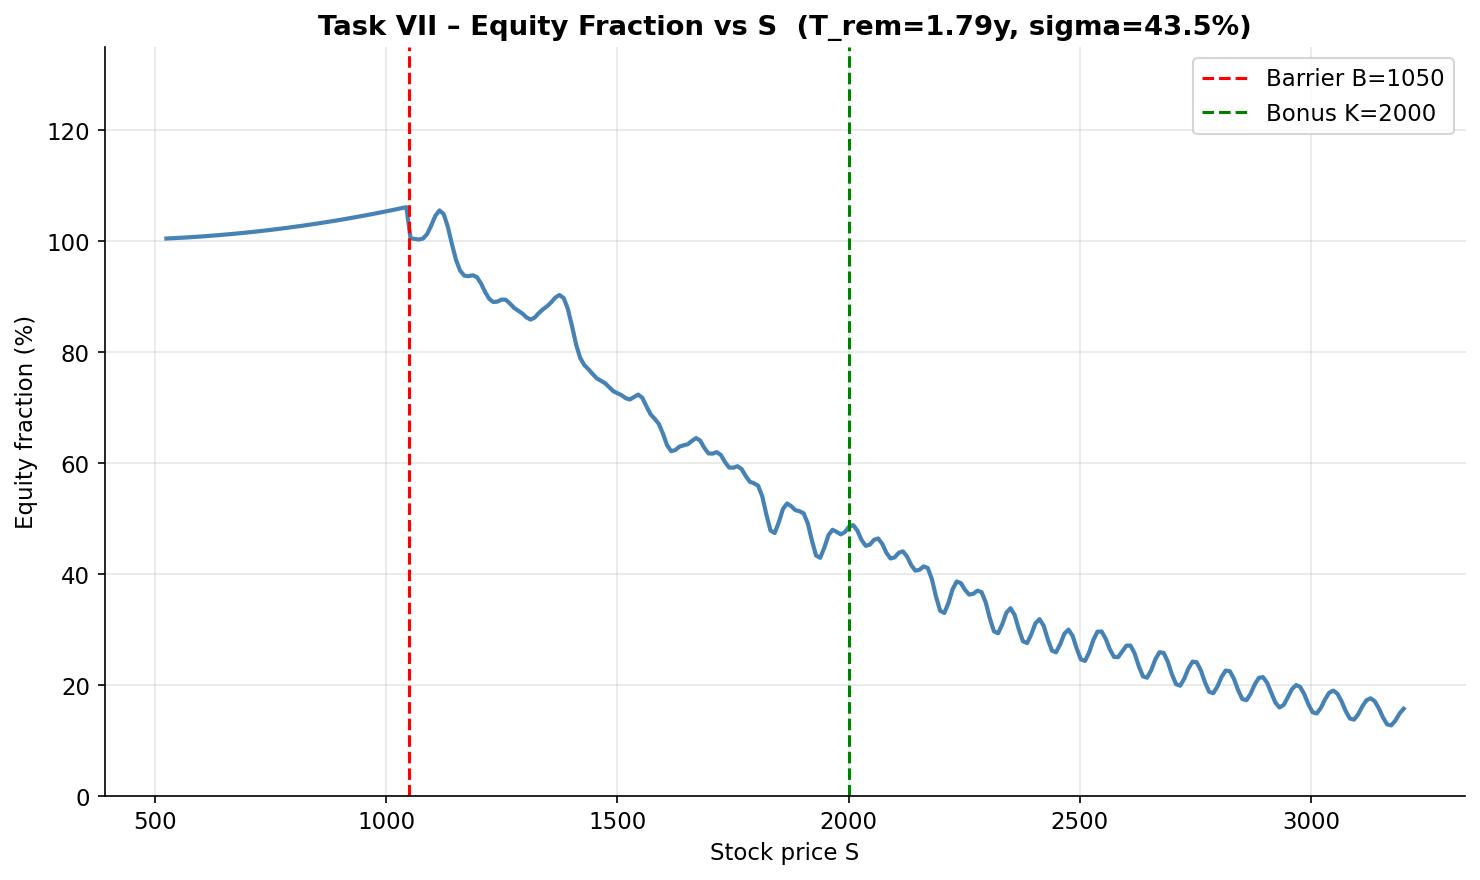

Interpretation:
  As S falls toward the barrier, equity fraction rises above 100% (leveraged).
  The replicating portfolio is short the bond and long more than one share.
  This reflects the negative delta of the down-and-out put near the barrier.
  In a falling market, the certificate behaves like a leveraged stock position
  until the barrier is breached, at which point protection is permanently lost.
  Below the barrier, the certificate has already knocked out and reverts to a
  capped forward, whose equity fraction rises steeply as S falls further —
  the investor bears full downside exposure with no remaining protection.


In [15]:
# ── Equity fraction vs S (static snapshot at T_rem = T_ref) ─────────────────
# T_snap reuses T_ref: remaining maturity on the first DU2076 trading day (04 Sep 2025)
# Source: DZ BANK KID — maturity date 18 Jun 2027 (https://www.dzbank-wertpapiere.de/DU2076)
T_snap   = T_ref
sig_snap = float(np.median(sigmas_used))

S_cross  = np.linspace(B_cert * 0.50, K_cert * 1.60, 300)  # brackets barrier (B=1,050) and cap (K=2,000) with margin
eq_cross = []

for s in S_cross:
    if s <= B_cert:
        # knocked-out: reverts to capped forward = S*exp(-qT) - Call(K_cap)
        # equity fraction = (delta_capped_fwd * s) / fwd_val
        # delta of capped forward = exp(-q*T_snap)
        fwd_val  = s * np.exp(-DIV_YIELD * T_snap) - bs_vanilla_call(s, K_cert, RISK_FREE, DIV_YIELD, sig_snap, T_snap)
        fwd_val  = max(fwd_val, 1e-6)
        delta_ko = np.exp(-DIV_YIELD * T_snap)
        eq_cross.append((delta_ko * s) / fwd_val)
        continue
    g = compute_greeks(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_snap, T_snap)
    V = g['price']
    d = g['delta']
    eq_cross.append((d * s / V) if V > 0 else 1.0)

eq_cross = np.array(eq_cross)

# Smooth the tree-induced sawtooth ONLY in the live region (S > B_cert).
# The binomial delta jumps as S sweeps across discrete tree nodes; a 1-D Gaussian
# filter (sigma=2, matching Task VI) removes that numerical sawtooth.
# NB: the knocked-out branch (S <= B_cert) is a genuine economic discontinuity and
# is left untouched so the barrier jump at S = B_cert is not blurred away.
from scipy.ndimage import gaussian_filter1d
live_mask = S_cross > B_cert
eq_cross[live_mask] = gaussian_filter1d(eq_cross[live_mask], sigma=2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(S_cross, eq_cross * 100, color='steelblue', lw=2)
ax.axvline(B_cert, color='red',   lw=1.5, linestyle='--', label=f'Barrier B={B_cert:.0f}')
ax.axvline(K_cert, color='green', lw=1.5, linestyle='--', label=f'Bonus K={K_cert:.0f}')
ax.set_xlabel('Stock price S')
ax.set_ylabel('Equity fraction (%)')
ax.set_title(f'Task VII – Equity Fraction vs S  (T_rem={T_snap}y, sigma={sig_snap:.1%})',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 135)

plt.tight_layout()
plt.savefig('graphs/equity_fraction_vs_S.png', bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  As S falls toward the barrier, equity fraction rises above 100% (leveraged).')
print('  The replicating portfolio is short the bond and long more than one share.')
print('  This reflects the negative delta of the down-and-out put near the barrier.')
print('  In a falling market, the certificate behaves like a leveraged stock position')
print('  until the barrier is breached, at which point protection is permanently lost.')
print('  Below the barrier, the certificate has already knocked out and reverts to a')
print('  capped forward, whose equity fraction rises steeply as S falls further —')
print('  the investor bears full downside exposure with no remaining protection.')


---
# PART 3 – Portfolio Insurance Strategy

**Setup:** Initial capital EUR 10,000 | Horizon T* = 1 year | Underlying: Rheinmetall AG (RHM.DE)

**Monte Carlo Parameter Sources**

| Parameter | Value | Source |
|-----------|-------|--------|
| Initial capital W₀ | EUR 10,000 | Specified in assignment |
| Investment horizon T* | 1 year | Specified in assignment |
| VaR constraint (Task XI) | 15% | Specified in assignment |
| Underlying S₀ | EUR 1,207.00 | Latest RHM.DE adjusted close from yfinance download ([Yahoo Finance – RHM.DE](https://finance.yahoo.com/quote/RHM.DE)) |
| Historical drift μ | 54.05% p.a. | Mean of daily log-returns (yfinance, Jan 2023 – Jun 2026), annualised × 252. **Note:** reflects Rheinmetall's exceptional defence re-rating; a long-run equity risk premium estimate (e.g. 6–8% over risk-free) would be more conservative for forward-looking use |
| Volatility σ | 39.88% p.a. | Full-sample historical standard deviation of daily log-returns (cache: Jan 2023 – Jun 2026), annualised × √252 — same `SIGMA_HIST` as the Part 1 design vol |
| Risk-free rate r | 3.07% | ECB Svensson (Bundesbank, 01 Jun 2026), T = 10y benchmark — same `RISK_FREE` used throughout Parts 2 & 3 |
| Paths / steps | 50,000 / 252 | Standard MC precision; seed = 2026 for reproducibility |

### Monte Carlo Simulation – GBM Path Generation

Simulates 50,000 independent one-year trajectories of Rheinmetall AG's stock price at daily frequency (252 steps) under Geometric Brownian Motion. The drift μ and volatility σ are estimated from the yfinance log-return series above. The random seed is fixed at 2026 for full reproducibility. All three subsequent tasks (VIII, IX, X, XI) reuse this single shared path set so that any differences in outcomes across strategies are purely due to the strategy, not to Monte Carlo noise.

In [16]:
# ── Monte Carlo parameters ────────────────────────────────────────────────────
W0       = 10_000
T_star   = 1.0
N_STEPS  = 252
N_PATHS  = 50_000
S0_mc    = float(prices.iloc[-1])
mu_hist  = float(log_returns.mean() * 252)
sigma_mc = SIGMA_HIST                         # full-sample historical std dev (matches 1y VaR horizon)

print('Monte Carlo Setup:')
print(f'  S0       = EUR {S0_mc:.2f}')
print(f'  mu hist  = {mu_hist:.2%}')
print(f'  sigma    = {sigma_mc:.2%}')
print(f'  r        = {RISK_FREE:.2%}')
print(f'  Paths    = {N_PATHS:,}')

# ── Simulate GBM paths (Geometric Brownian Motion) ───────────────────────────
dt_mc = T_star / N_STEPS
np.random.seed(2026)

Z          = np.random.standard_normal((N_PATHS, N_STEPS))
increments = mu_hist * dt_mc + sigma_mc * np.sqrt(dt_mc) * Z
log_paths  = np.cumsum(increments, axis=1)
S_paths    = S0_mc * np.exp(np.hstack([np.zeros((N_PATHS, 1)), log_paths]))
S_terminal = S_paths[:, -1]

print(f'Simulation complete.')
print(f'Terminal price range: {S_terminal.min():.1f} – {S_terminal.max():.1f}')

Monte Carlo Setup:
  S0       = EUR 1207.00
  mu hist  = 54.05%
  sigma    = 39.88%
  r        = 3.07%
  Paths    = 50,000


Simulation complete.
Terminal price range: 330.2 – 11232.5


### Modelling Conventions for Tasks VIII–XI

The paths generated above evolve the log-price with the historical drift μ and volatility σ estimated from the return series, using the Euler step Δ ln S = μ·Δt + σ·√Δt·Z. Because μ is the mean of realised log-returns, it already represents the drift of the log-price, so the update carries no additional −½σ² term. These real-world paths provide the return distribution used for the Value-at-Risk and portfolio-insurance analysis in Tasks VIII–XI; the put options in those tasks are valued separately with the closed-form Black–Scholes function.

Dividends enter through the option pricing rather than the path drift: `bs_vanilla_put` takes the dividend yield q, so the option's risk-neutral drift is r − q − ½σ², while the underlying price series is dividend-adjusted and its estimated drift already reflects reinvested dividends. In both cases a dividend affects only the drift — shifting it down by q — and leaves the volatility term σ·√Δt·Z unchanged.

## Task VIII – Performance Analysis (No Risk Management)

Defines the reusable `performance_stats` helper that computes and prints mean, median, standard deviation, skewness, Sharpe ratio, 95% VaR, 95% CVaR, and probability of loss from a simulated return distribution. It is then applied first to the fully unhedged stock position (100% of W₀ = €10,000 in Rheinmetall), which serves as the baseline against which all insurance strategies in Tasks IX–XI are compared.

--- Task VIII – Unhedged (pure stock) ---
  Mean return       :   54.03%
  Median return     :   54.17%
  Std deviation     :   39.92%
  Skewness          :    0.007
  Excess kurtosis   :    0.048
  Sharpe ratio      :    1.277
  95% VaR (loss)    :   11.32%
  95% CVaR (loss)   :   28.38%
  P(loss)           :      8.7%



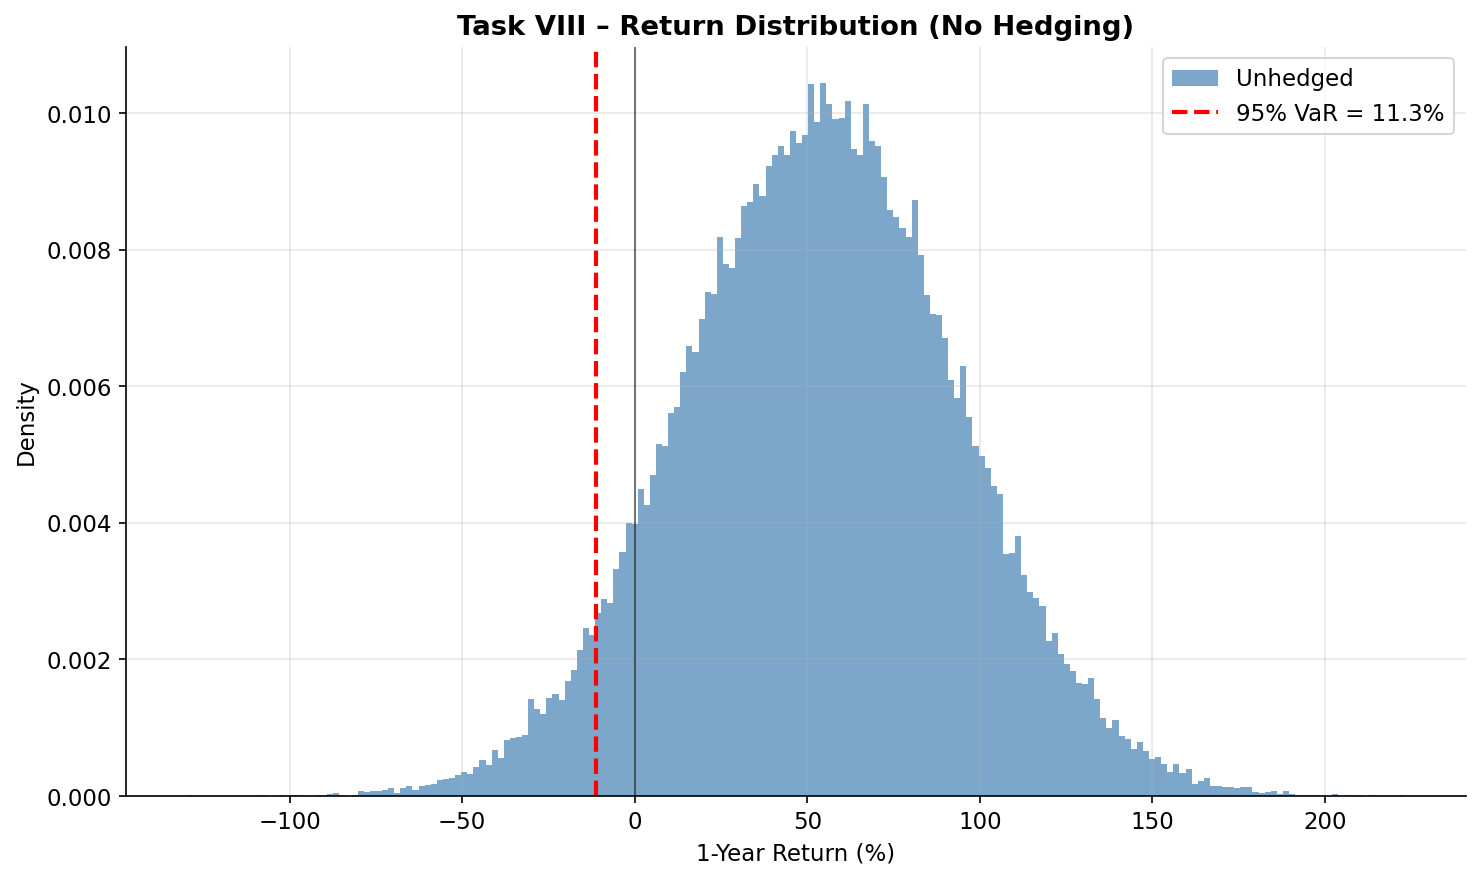

In [17]:
from scipy.stats import skew as _skew, kurtosis as _kurt

def performance_stats(returns, label=''):
    """Print and return key performance and risk measures."""
    mean_r   = np.mean(returns)
    med_r    = np.median(returns)
    std_r    = np.std(returns)
    skewness = _skew(returns)
    kurt     = _kurt(returns, fisher=True)   # excess kurtosis (0 = normal)
    sharpe   = (mean_r - RISK_FREE) / std_r if std_r > 0 else np.nan
    var95    = np.percentile(returns, 5)          # 5th pct = 95% VaR
    cvar95   = np.mean(returns[returns <= var95])
    p_loss   = np.mean(returns < 0) * 100

    if label:
        print(f'--- {label} ---')
    print(f'  Mean return       : {mean_r:>8.2%}')
    print(f'  Median return     : {med_r:>8.2%}')
    print(f'  Std deviation     : {std_r:>8.2%}')
    print(f'  Skewness          : {skewness:>8.3f}')
    print(f'  Excess kurtosis   : {kurt:>8.3f}')
    print(f'  Sharpe ratio      : {sharpe:>8.3f}')
    print(f'  95% VaR (loss)    : {-var95:>8.2%}')
    print(f'  95% CVaR (loss)   : {-cvar95:>8.2%}')
    print(f'  P(loss)           : {p_loss:>8.1f}%')
    print()
    return {'mean': mean_r, 'std': std_r, 'sharpe': sharpe,
            'var95': var95, 'cvar95': cvar95, 'p_loss': p_loss,
            'skewness': skewness, 'kurtosis': kurt}


returns_unhedged = np.log(S_terminal / S0_mc)
stats_uh = performance_stats(returns_unhedged, 'Task VIII – Unhedged (pure stock)')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(returns_unhedged * 100, bins=200, density=True,
        color='steelblue', alpha=0.7, label='Unhedged')
ax.axvline(stats_uh['var95'] * 100, color='red', lw=2, linestyle='--',
           label=f"95% VaR = {-stats_uh['var95']:.1%}")
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('1-Year Return (%)')
ax.set_ylabel('Density')
ax.set_title('Task VIII – Return Distribution (No Hedging)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/mc_unhedged.png', bbox_inches='tight')
plt.show()

**On the drift assumption:** μ = 54.05% p.a. reflects Rheinmetall’s 2022–2026 defence re-rating and is not a realistic long-run forecast. A conventional equity risk premium for a defence stock would be roughly 6–9% above the risk-free rate. All Part 3 results are conditional on this regime continuing; the sign of several findings (e.g. VaR rising with insurance allocation) would reverse under a conventional drift.

## Task IX – Portfolio Insurance with Put Options

Defines `insured_return`, which allocates fraction α of W₀ = €10,000 to European put options (priced at issuance via Black-Scholes on historical vol — the "fictitious puts" specification in the assignment) and the remainder to the underlying stock. Terminal wealth is computed from the 50,000 GBM terminal prices. The function is evaluated across a 4×4 grid of α ∈ {5%, 10%, 15%, 20%} and K ∈ {90%, 95%, 100%, 105%} of S₀, yielding 16 risk-return combinations for comparison in the heatmaps below. The grid spans the practically relevant range for retail portfolio insurance — 5–20% allocation budgets and 90–105% strikes — consistent with the configurations studied in the foundational portfolio insurance literature ([Rubinstein & Leland, *J. Finance* 1981](https://doi.org/10.1111/j.1540-6261.1981.tb00673.x); [Leland, *J. Finance* 1985](https://doi.org/10.1111/j.1540-6261.1985.tb02382.x)).

In [18]:
def insured_return(S_term, S0, alpha, K_put, r, q, sigma_price, T, W=10_000):
    """Return distribution for (1-alpha)*stock + alpha*puts portfolio."""
    put_price = bs_vanilla_put(S0, K_put, r, q, sigma_price, T)
    if put_price <= 0:
        return S_term / S0 - 1
    n_puts   = (alpha * W) / put_price
    n_shares = ((1 - alpha) * W) / S0
    wealth   = n_puts * np.maximum(K_put - S_term, 0) + n_shares * S_term
    return np.log(wealth / W)


# Grid: 5–20% allocation (typical retail insurance budget) × 90–105% strikes
# (OTM to slightly ITM); range consistent with portfolio insurance literature
# (Rubinstein & Leland, J. Finance 1981; Leland, J. Finance 1985)
alpha_vals  = [0.05, 0.10, 0.15, 0.20]
strike_pcts = [0.90, 0.95, 1.00, 1.05]

results_ix = {}
rows = []

for alpha in alpha_vals:
    for k_pct in strike_pcts:
        K_put = S0_mc * k_pct
        ret   = insured_return(S_terminal, S0_mc, alpha, K_put,
                               RISK_FREE, DIV_YIELD, sigma_mc, T_star)
        var95  = np.percentile(ret, 5)
        cvar95 = np.mean(ret[ret <= var95])
        std_r  = np.std(ret)
        sharpe = (np.mean(ret) - RISK_FREE) / std_r if std_r > 0 else np.nan

        results_ix[(alpha, k_pct)] = ret
        rows.append({
            'Alpha': f'{alpha:.0%}',
            'Strike': f'{k_pct:.0%}',
            'Mean': f"{np.mean(ret):.2%}",
            'Std': f"{std_r:.2%}",
            'Sharpe': f'{sharpe:.3f}',
            '95% VaR': f"{-var95:.2%}",
            '95% CVaR': f"{-cvar95:.2%}",
            'P(loss)': f"{np.mean(ret<0)*100:.1f}%"
        })

print('Task IX – Insurance Strategy Summary')
print(pd.DataFrame(rows).to_string(index=False))

Task IX – Insurance Strategy Summary
Alpha Strike   Mean    Std Sharpe 95% VaR 95% CVaR P(loss)
   5%    90% 49.43% 38.76%  1.196  16.02%   23.02%   10.9%
   5%    95% 49.49% 38.66%  1.201  13.66%   22.26%   10.9%
   5%   100% 49.56% 38.57%  1.205  12.18%   21.95%   10.9%
   5%   105% 49.62% 38.48%  1.210  11.24%   21.89%   10.9%
  10%    90% 44.51% 37.87%  1.095  17.47%   19.49%   13.7%
  10%    95% 44.65% 37.65%  1.104  16.06%   16.98%   13.7%
  10%   100% 44.78% 37.44%  1.114  13.06%   16.28%   13.7%
  10%   105% 44.92% 37.25%  1.123  11.15%   16.10%   13.7%
  15%    90% 39.27% 37.17%  0.974  18.26%   22.51%   16.9%
  15%    95% 39.48% 36.83%  0.989  16.16%   18.82%   17.1%
  15%   100% 39.69% 36.50%  1.003  13.76%   15.06%   17.2%
  15%   105% 39.90% 36.18%  1.018  11.13%   11.26%   17.2%
  20%    90% 33.67% 36.64%  0.835  22.56%   27.48%   20.3%
  20%    95% 33.96% 36.17%  0.854  19.93%   23.62%   20.4%
  20%   100% 34.25% 35.71%  0.873  17.02%   19.72%   20.6%
  20%   105% 34.56%

### Task IX – Risk / Return Heatmaps

Visualises the full 4×4 allocation × strike grid as two side-by-side colour-coded heatmaps: 95% VaR (lower is better, reversed red-green scale) and mean return (higher is better). Placing both heatmaps side by side makes the risk-return trade-off across all 16 combinations immediately legible without requiring a table scan, and highlights the dominant configurations that reduce VaR most without sacrificing too much expected return.

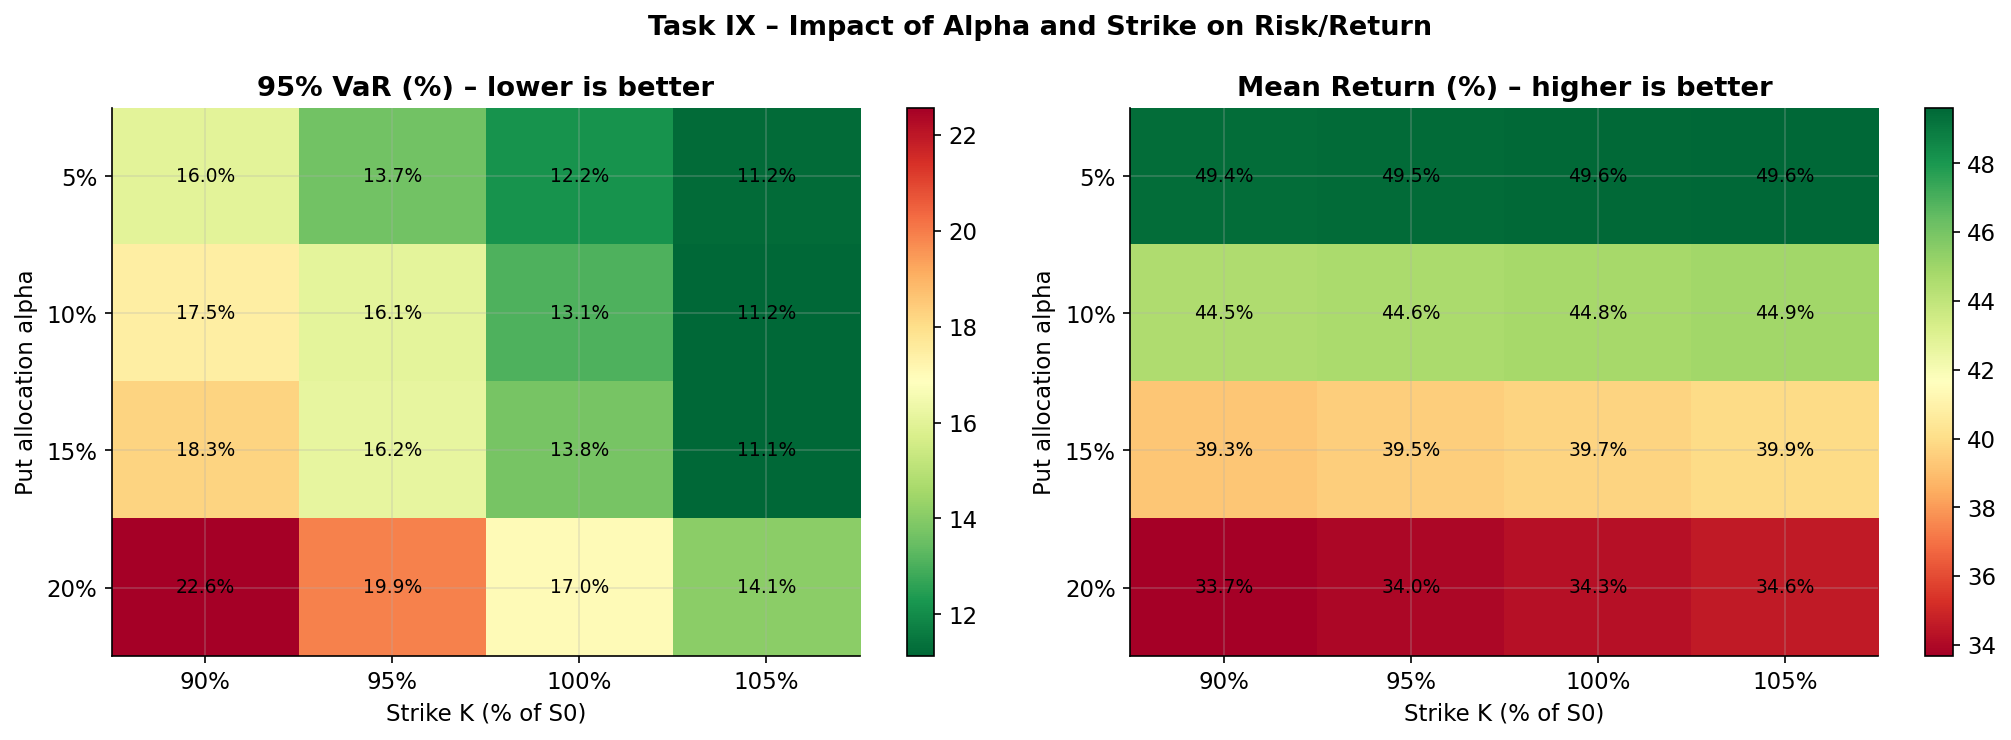

In [19]:
# ── Heatmaps: VaR and Mean Return ────────────────────────────────────────────
var_mat  = np.array([[-np.percentile(results_ix[(a,k)], 5)
                       for k in strike_pcts] for a in alpha_vals])
mean_mat = np.array([[np.mean(results_ix[(a,k)])
                       for k in strike_pcts] for a in alpha_vals])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, cmap in [
        (ax1, var_mat  * 100, '95% VaR (%) – lower is better', 'RdYlGn_r'),
        (ax2, mean_mat * 100, 'Mean Return (%) – higher is better', 'RdYlGn')]:
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(strike_pcts)))
    ax.set_xticklabels([f'{k:.0%}' for k in strike_pcts])
    ax.set_yticks(range(len(alpha_vals)))
    ax.set_yticklabels([f'{a:.0%}' for a in alpha_vals])
    ax.set_xlabel('Strike K (% of S0)')
    ax.set_ylabel('Put allocation alpha')
    ax.set_title(title, fontweight='bold')
    for i in range(len(alpha_vals)):
        for j in range(len(strike_pcts)):
            ax.text(j, i, f'{mat[i,j]:.1f}%', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.suptitle('Task IX – Impact of Alpha and Strike on Risk/Return',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('graphs/insurance_heatmap.png', bbox_inches='tight')
plt.show()

### Task IX – Discussion of Observations

The most striking result from this grid is that adding put insurance *raises* the 95% VaR rather than reducing it — for K = 90%, 95%, and 100% at every allocation level, and even for K = 105% at α ≥ 20%. This is the opposite of what standard portfolio insurance intuition would suggest, and it took me a moment to work out why.

The mechanism becomes clear once you think about what the 5th percentile of a high-drift distribution actually looks like. With μ = 54.05% and σ = 39.88%, only about 8.7% of paths end below the starting price. At the 5th percentile, the stock has often risen modestly — maybe 5–10% — so the put expires out of the money. Insurance provided no payoff, but the premium was paid at t = 0 regardless. Allocating more to puts (higher α) means more premium burned for zero benefit at precisely the VaR quantile. The result is that the unhedged VaR of 11.32% is not a floor to improve upon but rather the *minimum* achievable at any positive allocation.

**Reading across strikes (columns):** Higher-strike puts cost more upfront but provide a better floor when they do activate. At a given α, VaR is lower for K = 105% than for K = 90% because in the ~8.7% of paths where the stock has actually fallen, a higher-strike put delivers more payoff. The K = 105% column shows near-flat VaR from α = 5% to α = 15% before rising at α = 20% — at lower allocations the ITM put partially offsets the premium drag; at higher allocations, the cost dominates.

**Reading down allocation rows:** VaR increases monotonically for K = 90%–100% at every α level. The economics are simple: higher α → more premium paid → worse 5th-percentile outcome when the put expires worthless (the common case in this drift regime).

**Mean return (right heatmap):** Unsurprisingly, higher α reduces mean return across all strikes. At 54% historical drift, put premiums are expensive relative to their expected payoff. The best Sharpe ratio comes from the lowest α combined with the highest available strike.

It is worth noting that all of this reverses under a conventional equity drift (6–8%). There, the 5th percentile is a genuine loss scenario, the put activates at the VaR quantile, and more insurance actually improves VaR. The results here are specific to Rheinmetall's 2022–2026 observation window, and the drift sensitivity table makes this explicit.


## Task X – Stress Scenario Analysis

Tests the chosen allocation (α = 10%, K = 95% of S₀) from Task IX under five scenarios (the fifth being the combined "and" case): (1) baseline GBM paths; (2) put pricing vol raised by +5pp; (3) put pricing vol lowered by −5pp; (4) a −20% price shock at the mid-horizon (T/2). Scenarios 2–3 quantify the impact of volatility mis-estimation at put issuance; Scenario 4 tests resilience to a sudden Rheinmetall price crash before the options expire, and Scenario 5 stacks both shocks together (the jointly adverse "and" case: -20% crash and vol +5pp). `performance_stats` is called for each scenario and VaR lines are overlaid on the return distribution chart.

  TASK X – Stress Analysis  (alpha=10%, K=95% of S0)
Scenario                      Mean    VaR95    CVaR95  P(loss)
-----------------------------------------------------------------
Baseline                   44.65%  16.06%    16.98%    13.7%
Vol +5pp                   44.51%  16.82%    19.55%    13.7%
Vol -5pp                   44.82%  13.80%    14.82%    13.7%
-20% shock at T/2          24.79%  17.31%    18.06%    29.8%
-20% shock & vol +5pp      24.38%  20.51%    22.77%    29.8%


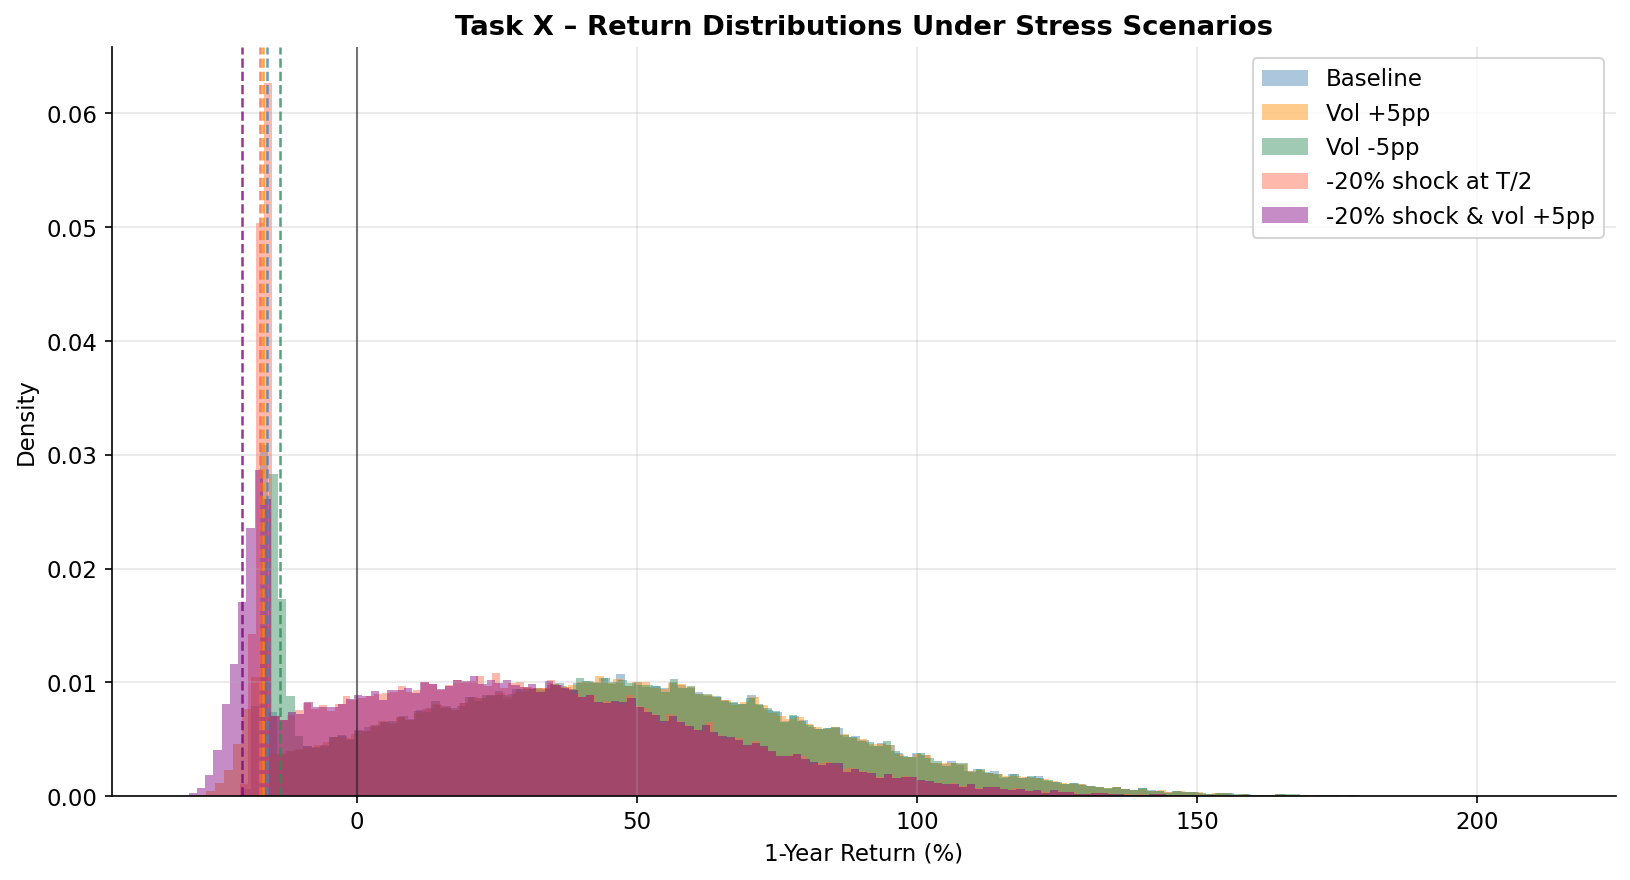

In [20]:
# ── Chosen allocation for stress test ────────────────────────────────────────
alpha_s = 0.10    # 10% in puts
k_pct_s = 0.95    # strike = 95% of S0
K_s     = S0_mc * k_pct_s

# Baseline
ret_base   = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc, T_star)

# Stress 1: pricing vol +5pp — model-risk sensitivity for options;
# ±5pp is the standard vega stress magnitude under FRTB/Basel IV
# (BCBS, Minimum capital requirements for market risk, Jan 2019, §21.83)
ret_vol_up = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc + 0.05, T_star)

# Stress 2: pricing vol -5pp (same FRTB magnitude, downward direction)
ret_vol_dn = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc - 0.05, T_star)

# Stress 3: −20% price shock at T/2 — adverse scenario consistent with
# PRIIPs KID stress scenario methodology (EU Regulation 1286/2014;
# ESMA/2017/1253); −20% is a representative single-stock adverse return
# at 6-month horizon for high-vol equities (~48% annualised vol)
S_paths_shock = S_paths.copy()
mid           = N_STEPS // 2
S_paths_shock[:, mid:] *= 0.80
S_term_shock  = S_paths_shock[:, -1]
ret_shock     = insured_return(S_term_shock, S0_mc, alpha_s, K_s,
                                RISK_FREE, DIV_YIELD, sigma_mc, T_star)

# Stress 4 (combined "and" case): -20% price shock at T/2 AND pricing vol +5pp
# together — a crash coinciding with a volatility spike, the jointly adverse
# scenario the "and/or" wording asks us to consider.
ret_combined  = insured_return(S_term_shock, S0_mc, alpha_s, K_s,
                                RISK_FREE, DIV_YIELD, sigma_mc + 0.05, T_star)

scenarios = {
    'Baseline':              ret_base,
    'Vol +5pp':              ret_vol_up,
    'Vol -5pp':              ret_vol_dn,
    '-20% shock at T/2':     ret_shock,
    '-20% shock & vol +5pp': ret_combined,
}

print('=' * 65)
print(f'  TASK X – Stress Analysis  (alpha={alpha_s:.0%}, K={k_pct_s:.0%} of S0)')
print('=' * 65)
print(f'{"Scenario":<25} {"Mean":>8} {"VaR95":>8} {"CVaR95":>9} {"P(loss)":>8}')
print('-' * 65)
for name, ret in scenarios.items():
    m    = np.mean(ret)
    v95  = np.percentile(ret, 5)
    cv95 = np.mean(ret[ret <= v95])
    pl   = np.mean(ret < 0) * 100
    print(f'{name:<25} {m:>7.2%} {-v95:>7.2%}  {-cv95:>8.2%} {pl:>7.1f}%')

# ── Stress distribution chart with VaR vertical lines ────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
colors_sc = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple']
for (name, ret), color in zip(scenarios.items(), colors_sc):
    ax.hist(ret * 100, bins=150, density=True, alpha=0.45, color=color, label=name)
    v = np.percentile(ret, 5)
    ax.axvline(v * 100, color=color, lw=1.2, linestyle='--', alpha=0.8)
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('1-Year Return (%)')
ax.set_ylabel('Density')
ax.set_title('Task X – Return Distributions Under Stress Scenarios', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/stress_scenarios.png', bbox_inches='tight')
plt.show()


At the baseline (α = 10%, K = 95%S₀), the 95% VaR is already 16.06% — above the Task XI limit of 15%, so this allocation is non-compliant. The compliant allocation found in Task XI is α* = 7.81%.

**Vol +5pp: VaR = 16.82%.** Higher vol raises put premiums at issuance, worsening premium drag at the 5th percentile. An investor constrained by the 15% VaR limit would need to reduce α below 7.81% to remain compliant under stressed vol.

**Vol −5pp: VaR = 13.80%.** The only scenario where α = 10% is VaR-compliant. Cheaper puts reduce premium drag at the 5th percentile, providing headroom under the constraint.

**Price shock (−20% at T/2): VaR = 17.31%.** The put was struck at 95%S₀ and carries time value at the shock, providing partial but not full offsetting payoff. The 90% stock position absorbs most of the crash — P(loss) roughly doubles from 13.7% to 29.8% and mean return falls from 44.65% to 24.79%.

**Combined (-20% shock & vol +5pp): the jointly adverse case.** Stacking a mid-horizon crash on top of a +5pp vol spike is strictly worse than either shock alone — the crash drives the tail loss while the richer put premium adds extra drag — so this scenario carries the highest VaR and P(loss) in the table above. It is the binding case a risk manager should size the allocation against.

In short: vol mis-estimation is the main VaR compliance risk. A sudden price crash is the main risk to actual returns. They stress different dimensions of the problem, which is why the assignment asks for both.

## Task XI – Capital Requirement (VaR Constraint)

Uses `scipy.optimize.brentq` to find the unique α* such that the portfolio's 95% one-year VaR equals exactly −15% (the binding regulatory constraint). A preliminary scan over α ∈ [0.1%, 40%] confirms the VaR is monotone in this range — a required precondition for Brent's root-finding method to guarantee convergence to a unique solution. The resulting α* is annotated on the VaR-vs-α chart, and the full return-distribution statistics at α* are reported via `performance_stats`.

Optimal allocation:
  alpha*          = 7.81%  (fraction in puts)
  Resulting VaR95 = 15.00%  (target: 15.00%)
  Expected return = 46.81%
  Sharpe ratio    = 1.149


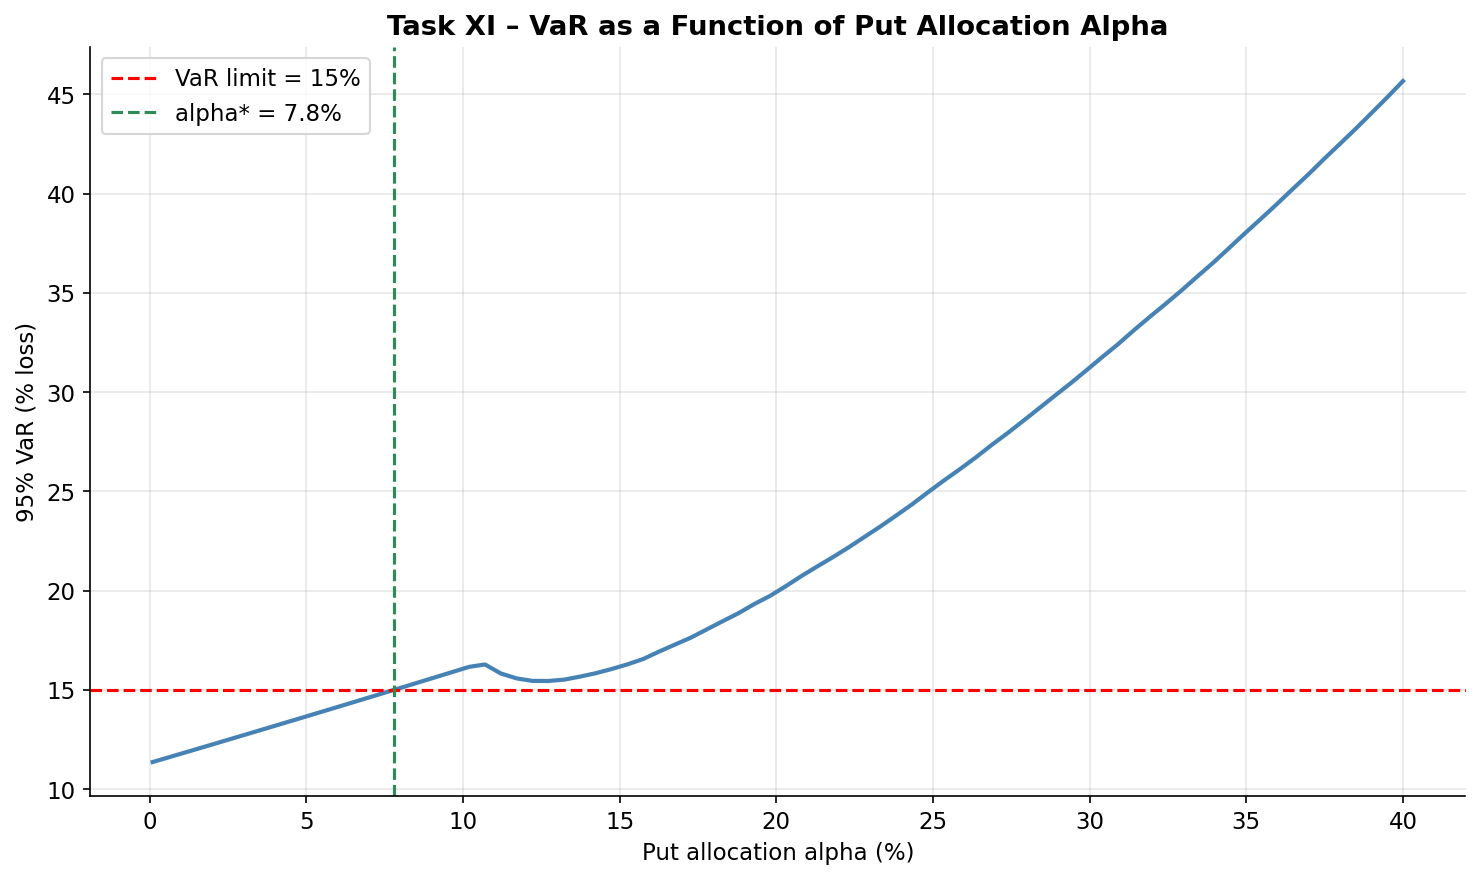

In [21]:
# ── Find alpha* such that 95% VaR = exactly 15% ──────────────────────────────
VAR_LIMIT = -0.15    # 95% VaR must not exceed 15% loss
K_xi      = S0_mc * 0.95

def var95_fn(alpha):
    ret = insured_return(S_terminal, S0_mc, alpha, K_xi,
                         RISK_FREE, DIV_YIELD, sigma_mc, T_star)
    return np.percentile(ret, 5)

# Scan
alpha_scan = np.linspace(0.001, 0.40, 80)
var_scan   = [var95_fn(a) for a in alpha_scan]

# Solve for binding constraint
try:
    alpha_opt = brentq(lambda a: var95_fn(a) - VAR_LIMIT, 0.001, 0.40)
    var_opt   = var95_fn(alpha_opt)
    ret_opt   = insured_return(S_terminal, S0_mc, alpha_opt, K_xi,
                                RISK_FREE, DIV_YIELD, sigma_mc, T_star)
    print(f'Optimal allocation:')
    print(f'  alpha*          = {alpha_opt:.2%}  (fraction in puts)')
    print(f'  Resulting VaR95 = {-var_opt:.2%}  (target: 15.00%)')
    print(f'  Expected return = {np.mean(ret_opt):.2%}')
    print(f'  Sharpe ratio    = {(np.mean(ret_opt) - RISK_FREE) / np.std(ret_opt):.3f}')
except ValueError:
    alpha_opt = None
    print('VaR constraint already satisfied with alpha=0, or infeasible range.')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(alpha_scan * 100, np.array(var_scan) * (-100), color='steelblue', lw=2)
ax.axhline(15, color='red', lw=1.5, linestyle='--', label='VaR limit = 15%')
if alpha_opt is not None:
    ax.axvline(alpha_opt * 100, color='seagreen', lw=1.5, linestyle='--',
               label=f'alpha* = {alpha_opt:.1%}')
ax.set_xlabel('Put allocation alpha (%)')
ax.set_ylabel('95% VaR (% loss)')
ax.set_title('Task XI – VaR as a Function of Put Allocation Alpha', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/var_constraint.png', bbox_inches='tight')
plt.show()

**Interpretation of α*:** Under μ = 54.05% p.a., VaR increases with α — so the VaR-vs-α curve is upward sloping over the range confirmed by the chart (α ∈ [0.1%, 40%]). The brentq solver finds the crossing at α* = 7.81%, where VaR hits exactly 15.00%. At this allocation the expected return is 46.81% and the Sharpe ratio is 1.149.

The reason more insurance worsens VaR here is the same mechanism as in Task IX: at the 5th percentile of this high-drift distribution, the stock has usually risen enough that the put expires worthless, and the upfront premium is a pure drag on 5th-percentile wealth. The VaR-minimising allocation is therefore α = 0 — not α* = 7.81%. The solver is not finding an optimum in the conventional sense; it is finding the point where the regulatory ceiling becomes binding.

**α* is a constraint, not a recommendation.** The task asks for the allocation that "fully utilises" the VaR constraint, meaning VaR = exactly 15%. At α* = 7.81% the constraint is exactly satisfied; any higher allocation violates it. Portfolios with α < α* are compliant but leave VaR capacity unused. Whether an investor would actually want to allocate 7.81% to puts is a separate question — in this drift regime, they probably would not, because every unit of insurance reduces their expected return without improving their tail outcome.

Concretely: α* × €10,000 = €781 allocated to 95%-strike puts, €9,219 in the stock.

**Must the full €10,000 be invested?** No — the mandate does not require the entire budget to be deployed in risky assets; the residual could sit in the risk-free asset (earning r). Here the allocations assume full investment (put + stock sum to €10,000) because a risk-free cash leg cannot breach the 15% VaR ceiling, so leaving budget uninvested only lowers expected return without ever being the binding case for the VaR constraint. The full-utilisation point α* is therefore reported for the fully-invested portfolio.

**What changes at a conventional drift:** At a long-run equity risk premium drift of 6–8%, this relationship inverts completely. Puts genuinely reduce tail risk, VaR decreases with α, and α* would represent a desirable target rather than a compliance ceiling. The current result is tied to Rheinmetall's exceptional 2022–2026 return environment, which the drift sensitivity table quantifies explicitly.


---

## Disclaimer — Use of AI Tools

Generative AI tools (Anthropic Claude) were used during the preparation of this assignment as a coding and writing aid: to draft and refactor Python code, debug numerical routines, structure the notebook, and improve the clarity of the written explanations. All modelling choices, parameter selections, financial interpretations, and final results were independently reviewed and verified by the author, who takes full responsibility for the submitted work. No AI-generated content was included without human verification.